# Projeto 2 - Ciencia dos Dados

### --- Grupo 6 ---

##### - João Victor Ribeiro Lopes
##### - Victor Lucius
##### - Alline Oliveira
##### - Isaac Reis
___


Importando Bibliotecas:

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
pd.set_option('display.max_columns', None)

In [2]:
print('Esperamos trabalhar no diretório')
print(os.getcwd())

Esperamos trabalhar no diretório
c:\Users\isaac\OneDrive\Área de Trabalho\Projeto2\Projeto-2-Cdados


___

# 1 - Introdução 

O Exame Nacional do Ensino Médio (ENEM) foi instituído em 1998 com o objetivo de avaliar o desempenho escolar dos estudantes ao término da educação básica. Em 2009, o exame aperfeiçoou sua metodologia e consolidou-se como o principal mecanismo de acesso à educação superior no Brasil. No entanto, para entender o ENEM em sua totalidade, é preciso enxergá-lo não apenas como uma prova de 180 questões e uma redação, mas como um mecanismo complexo que reflete a realidade social do Brasil, na qual indicadores socioeconômicos, demográficos e geográficos impactam profundamente a média final do participante.

Condições socioeconômicas de estudantes que concorrem ao Enem afetam em até 85% o resultado final no exame. É o que mostra estudo desenvolvido pelo cientista de dados e mestre em Economia pela Universidade de Brasília, Leonardo Sales. A pesquisa leva em contas fatores como a renda de cada aluno, se a escola é pública ou privada e se a família incentiva ou não os estudos.
UFMG, 8 nov. 2018. Disponível em: https://www3.ufmg.br/comunicacao/noticias/fatores-socioeconomicos-determinam-nota-do-enem-diz-estudo. Acesso em: 20 abr. 2026. 

Essa reflexão se torna ainda mais urgente quando observamos cursos de altíssima concorrência, como *Direito. Nesses cenários, a aprovação no SiSU exige uma excelência direcionada, pois a nota de corte é definida por uma **média ponderada* — atribuindo peso máximo (3) às áreas de Redação, Linguagens e Ciências Humanas, e peso menor (1) para Matemática e Ciências da Natureza. Com essa métrica, cada décimo na nota final é decisivo, evidenciando que o desempenho do candidato raramente é fruto apenas do seu esforço individual, mas sim do ambiente e das oportunidades que o cercam.

Neste projeto, adicionamos a essa equação um fator histórico sem precedentes: o ano de *2020, que marcou o ápice da pandemia de COVID-19 e escancarou a desigualdade na educação básica brasileira. Em contraste, analisamos **2023*, que representa o cenário de retomada pós-pandêmica.

Para o desenvolvimento deste projeto, utilizamos a análise de microdados, que representam um nível mais  detalhado de um levantamento estatístico. Enquanto dados agregados oferecem apenas visões generalistas, os microdados permitem acessar a unidade individual da pesquisa: no caso do ENEM, cada linha da base de dados corresponde às respostas e ao desempenho específico de um único candidato.
Essa escala de detalhamento é fundamental, pois possibilita a filtragem do público-alvo desejado. Além disso, os microdados são a base para o cálculo da Média Ponderada do ENEM (MPE), que atua como a nossa variável principal (target) e também é possível usufruir da análise de indicadores macroeconômicos na qual permite investigar se o contexto econômico e social onde o aluno vive e estuda impacta diretamente o seu desempenho e suas chances de ingresso em cursos de alta concorrência. Foi utilizado o  PIB Municipal que representa a soma de todos os bens e serviços finais produzidos em um município. Ele funciona como um termômetro da riqueza da cidade onde a escola do candidato está localizada e Índice FIRJAN que  acompanha anualmente o desenvolvimento humano, econômico e social das cidades com base em três pilares fundamentais: emprego, renda, educação e saúde.

Nosso objetivo é responder a uma pergunta central: *Até que ponto os indicadores macroeconômicos de um município e os dados socioeconômicos do candidato conseguem prever a sua Nota Ponderada para o curso de Direito no ENEM?*
___

# 2 - EXPORTANDO DADOS

Os dados sobre o ENEM foram retirados do INEP, os dados apresentam formato CSV e são acompanhados por um dicionário, já que algumas informações são substituídas por códigos para deixar as bases de dados mais leves. Os dados do desenvolvimento municipal FIRJAN foram retirados do site oficial do FIRJAN em formato CSV, os dados do PIB foram extraídos do IBGE, formato xlsx.

In [3]:
# Carregando os dados
enem2023 = pd.read_csv('../microdados_enem_2023/DADOS/MICRODADOS_ENEM_2023.csv',encoding='ISO-8859-1',sep=';')

In [4]:
print(f'Número de linhas: {enem2023.shape[0]}\nNúmero de colunas: {enem2023.shape[1]}')

Número de linhas: 3933955
Número de colunas: 76


In [5]:
enem2020 = pd.read_csv('../microdados_enem_2020/DADOS/MICRODADOS_ENEM_2020.csv',encoding='ISO-8859-1',sep=';')

In [6]:
print(f'Número de linhas: {enem2020.shape[0]}\nNúmero de colunas: {enem2020.shape[1]}')

Número de linhas: 5783109
Número de colunas: 76


In [7]:
firjan = pd.read_csv('../Serie-Historica-IFDM-2013-a-2023(IFDM Geral).csv',encoding='ISO-8859-1',sep=';')

In [8]:
print(f'Número de linhas: {firjan.shape[0]}\nNúmero de colunas: {firjan.shape[1]}')

Número de linhas: 5570
Número de colunas: 36


In [9]:
pib = pd.read_excel('../PIB dos Municípios - base de dados 2010-2023.xlsx')

In [10]:
print(f'Número de linhas: {pib.shape[0]}\nNúmero de colunas: {pib.shape[1]}')

Número de linhas: 77965
Número de colunas: 43


___
# FILTRANDO DADOS

Primeiro, excluímos as linhas que dificultariam a análise: Treineiros, Faltou em alguma prova, redação irregular (receberam 0), que não estavam concluindo o ensino médio no ano, não eram brasileiros, ensino não convencional (Educação Especial - Modalidade Substitutiva), não responderam o município onde estudaram, não responderam o questionário socioeconômico. Depois, excluímos as colunas de pouca relevância: Todos que já foram filtrados para um único valor, respostas na prova, gabarito, nota indivídual da redação, código da prova...

In [11]:
#removendo linhas desnecessárias:
enem2020filtrado = enem2020[
    (enem2020['IN_TREINEIRO'] == 0) &
    (enem2020['TP_PRESENCA_CN'] == 1) &
    (enem2020['TP_PRESENCA_CH'] == 1) &
    (enem2020['TP_PRESENCA_LC'] == 1) &
    (enem2020['TP_PRESENCA_MT'] == 1) &
    (enem2020['TP_STATUS_REDACAO'] == 1) &
    (enem2020['TP_ST_CONCLUSAO'] == 2) &
    (enem2020['TP_NACIONALIDADE'] == 1) &
    (enem2020['TP_ENSINO'] == 1) &
    (enem2020['NO_MUNICIPIO_ESC'].notna()) &
    (enem2020['Q001'].notna())
]
enem2023filtrado = enem2023[
    (enem2023['IN_TREINEIRO'] == 0) &
    (enem2023['TP_PRESENCA_CN'] == 1) &
    (enem2023['TP_PRESENCA_CH'] == 1) &
    (enem2023['TP_PRESENCA_LC'] == 1) &
    (enem2023['TP_PRESENCA_MT'] == 1) &
    (enem2023['TP_STATUS_REDACAO'] == 1) &
    (enem2023['TP_ST_CONCLUSAO'] == 2) &
    (enem2023['TP_NACIONALIDADE'] == 1) &
    (enem2023['TP_ENSINO'] == 1) &
    (enem2023['NO_MUNICIPIO_ESC'].notna()) &
    (enem2023['Q001'].notna())
]



Para a análise, foram selecionadas onze variáveis explicativas (features) que descrevem o perfil dos candidatos. As variáveis foram escolhidas de forma a abranger dimensões socioeconômicas, educacionais e geográficas, possibilitando uma análise mais ampla do desempenho na Média Ponderada via ENEM (MPE).

|i|Nome da coluna|Descrição|
|-|--------------|---------|
|1|TP_SEXO|Sexo|
|2|TP_COR_RACA|Cor/raça|
|3|TP_ESCOLA|Tipo de escola do Ensino Médio|
|4|TP_LOCALIZACAO_ESC|Local da escola do Ensino Médio|
|5|Q025|Na sua residência tem acesso à Internet?|
|6|Q024|Na sua residência tem computador?|
|7|Q003|Qual é a ocupação principal do pai?|
|8|Q004|Qual é a ocupação principal da mãe?|
|9|Q006|Qual é a renda mensal de sua família? (Some a sua renda com a dos seus familiares.)|
|10|Q001|Até que série seu pai ou responsável masculino estudou?|
|11|Q002|Até que série sua mãe ou responsável feminina estudou?|

In [12]:


#filtrar colunas:
cols = [
    'TP_SEXO',              # feature1
    'TP_COR_RACA',          # feature2
    'TP_ESCOLA',            # feature3
    'NO_MUNICIPIO_ESC',
    'CO_MUNICIPIO_ESC',
    'TP_LOCALIZACAO_ESC',   # feature4
    'NU_NOTA_CN',
    'NU_NOTA_CH',
    'NU_NOTA_LC',
    'NU_NOTA_MT',
    'NU_NOTA_REDACAO',
    'Q025',                 # feature5
    'Q024',                 # feature6
    'Q003',                 # feature7
    'Q004',                 # feature8
    'Q006',                  # feature9
    'Q001',                  # feature10
    'Q002'                  # feature11
]

enem2020filtrado = enem2020filtrado[cols]
enem2023filtrado = enem2023filtrado[cols]

Um processo semelhante foi feito nos indicadores para que só restassem o código do município e o índicie de interesse

In [13]:
#filtrar linhas
pib2020filtrado = pib[
    (pib['Ano']==2020)
]
pib2023filtrado = pib[
    (pib['Ano']==2023)
]
#filtrar colunas
pib2020filtrado = pib2020filtrado[
    ['Produto Interno Bruto per capita, \na preços correntes\n(R$ 1,00)', 'Código do Município']
]
pib2023filtrado = pib2023filtrado[
    ['Produto Interno Bruto per capita, \na preços correntes\n(R$ 1,00)', 'Código do Município']
]
firjan2020filtrado = firjan[
    ['IFDM 2020','COD_MUNIC']
]
firjan2023filtrado = firjan[
    ['IFDM 2023','COD_MUNIC']
]

___
# JUNÇÃO DOS RESULTADOS E CRIAÇÃO DA TARGET

Com os dados de interesse filtrados, temos que juntá-los duas bases de dados, uma para 2023 e uma para 2020

In [14]:
#ENEM
#CRIAR TARGET (média final)
enem2023filtrado['TARGET'] = 0.75*(0.40*enem2023filtrado['NU_NOTA_LC'] + 0.20*enem2023filtrado['NU_NOTA_MT'] + 0.30*enem2023filtrado['NU_NOTA_CH'] + 0.10*enem2023filtrado['NU_NOTA_CN']) + 0.25*enem2023filtrado['NU_NOTA_REDACAO']
enem2020filtrado['TARGET'] = 0.75*(0.40*enem2020filtrado['NU_NOTA_LC'] + 0.20*enem2020filtrado['NU_NOTA_MT'] + 0.30*enem2020filtrado['NU_NOTA_CH'] + 0.10*enem2020filtrado['NU_NOTA_CN']) + 0.25*enem2020filtrado['NU_NOTA_REDACAO']
enem2020filtrado = enem2020filtrado.rename(columns={
    'CO_MUNICIPIO_ESC': 'cod_municipio'
})

enem2023filtrado = enem2023filtrado.rename(columns={
    'CO_MUNICIPIO_ESC': 'cod_municipio'
})


#PIB
pib2020filtrado = pib2020filtrado.rename(columns={
    'Código do Município': 'cod_municipio',
    'Produto Interno Bruto per capita, \na preços correntes\n(R$ 1,00)': 'pib_per_capita'
})

pib2023filtrado = pib2023filtrado.rename(columns={
    'Código do Município': 'cod_municipio',
    'Produto Interno Bruto per capita, \na preços correntes\n(R$ 1,00)': 'pib_per_capita'
})


#FIRJAN
firjan2020filtrado = firjan2020filtrado.rename(columns={
    'COD_MUNIC': 'cod_municipio',
    'IFDM 2020': 'ifdm'
})

firjan2023filtrado = firjan2023filtrado.rename(columns={
    'COD_MUNIC': 'cod_municipio',
    'IFDM 2023': 'ifdm'
})

enem2020filtrado['cod_municipio'] = (
    enem2020filtrado['cod_municipio']
    .astype(str)
    .str[:6]
    .astype(int)
)

enem2023filtrado['cod_municipio'] = (
    enem2023filtrado['cod_municipio']
    .astype(str)
    .str[:6]
    .astype(int)
)

# PIB
pib2020filtrado['cod_municipio'] = (
    pib2020filtrado['cod_municipio']
    .astype(str)
    .str[:6]
    .astype(int)
)

pib2023filtrado['cod_municipio'] = (
    pib2023filtrado['cod_municipio']
    .astype(str)
    .str[:6]
    .astype(int)
)
#PADRONIZAÇÃO
for df in [enem2020filtrado, enem2023filtrado,
           pib2020filtrado, pib2023filtrado, 
           firjan2020filtrado, firjan2023filtrado]:
    
    df['cod_municipio'] = pd.to_numeric(df['cod_municipio'], errors='coerce').astype('Int64')

#MERGE
enem2020_final = enem2020filtrado.merge(
    pib2020filtrado, on='cod_municipio', how='left'
).merge(
    firjan2020filtrado, on='cod_municipio', how='left'
)

enem2023_final = enem2023filtrado.merge(
    pib2023filtrado, on='cod_municipio', how='left'
).merge(
    firjan2023filtrado, on='cod_municipio', how='left'
)


#RENOMEAR FINAL
enem2020_final.rename(columns={
    'cod_municipio': 'MUNICIPIO_ESCOLARIDADE',
    'pib_per_capita': 'PIB_MUNICIPAL_PER_CAPITA',
    'ifdm': 'IFDM'
}, inplace=True)

enem2023_final.rename(columns={
    'cod_municipio': 'MUNICIPIO_ESCOLARIDADE',
    'pib_per_capita': 'PIB_MUNICIPAL_PER_CAPITA',
    'ifdm': 'IFDM'
}, inplace=True)

In [15]:
enem2020.head()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025
0,200006271946,2020,11,F,1,2,1,1,11,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1501402,Belém,15,PA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,200001195856,2020,11,M,2,3,1,1,11,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2408102,Natal,24,RN,1,1,1,1,702.0,689.0,693.0,698.0,604.1,661.7,595.3,711.3,BCBDBDCCCDBDDBADEEACEEAECBECCDBCACDEBEECEBAAE,BCAECABCDCEBDBBBDAABABACBCDDDBDDBABDAADACACBC,99999CADDEDADBAABEAADAAAADCADAABDCCBEECAEECAAC...,EBEBDEDAECBADCADDABACAEDBEEEAEADCCBCEACDACEBB,1,ABBACBCCCDDDDBAEEBECEDACABDCBEDAECDABECCBBADE,BCEECDBCCDEBDBBBBEAAAEACBCDDDBDDBABDABDDBAABC,99999CBDDEDBDBACECABAAAEAECCDCABCBBBBEEDCECAAE...,BBEADECAECBBXCEBADBACAEDACEDADAADCBCCBBDABBEE,1.0,120.0,120.0,120.0,120.0,100.0,580.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,200001943954,2020,4,F,2,3,2,2,0,2,1.0,0,2927408.0,Salvador,29.0,BA,2.0,1.0,1.0,2927408,Salvador,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B,C,A,D,3.0,B,A,B,A,A,A,B,A,B,A,B,A,A,B,A,A,A,A,A,A
3,200001908998,2020,2,M,1,3,1,2,0,2,1.0,0,3547304.0,Santana de Parnaíba,35.0,SP,3.0,1.0,1.0,3547304,Santana de Parnaíba,35,SP,1,1,1,1,700.0,688.0,692.0,696.0,620.8,675.0,624.2,759.4,EBEDCCCDCBDBAECAECCECEACCBAABBBCEABCAAAEBEBAE,DABCCACCBCCDCADBDCBAAEBDDBAABDBAEBEBBABDABDBE,DCEAB99999AADAECCEBCDDDCBABDDABBCEEBAEDDDADEBE...,CBDBDCCDDEECBAABBBADEDEDBECDEBBADAEBAABBECBBA,0,BDECCACBEBDEAEDAECCBAEABCCEADDBBCADCBDDEBDBAC,DABCCAECBABECADBDCCABDBCDDAABDBAEBEBBDBDDBDBE,DCEAD99999AADACCCCBBDDCABAECAABBEECBAEDDBBEEBE...,EBDBXCCDAEECBAABABAEDDEDAECBCDCADEEBBABBACBCA,1.0,140.0,200.0,140.0,120.0,160.0,760.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,200001634757,2020,4,F,1,3,2,1,1,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3121605,Diamantina,31,MG,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B,G,B,B,3.0,B,A,B,D,A,A,B,A,B,A,A,A,A,B,A,B,B,A,A,B


In [16]:
enem2023_final.head(5)

,TP_SEXO,TP_COR_RACA,TP_ESCOLA,NO_MUNICIPIO_ESC,MUNICIPIO_ESCOLARIDADE,TP_LOCALIZACAO_ESC,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q025,Q024,Q003,Q004,Q006,Q001,Q002,TARGET,PIB_MUNICIPAL_PER_CAPITA,IFDM
0,F,3,2,Fortaleza,230440,1.0,459.0,508.5,507.2,466.7,880.0,B,A,B,B,C,D,D,591.0025,35796.74,"0,7389"
1,F,3,2,Quixadá,231130,1.0,402.5,379.2,446.9,338.3,560.0,A,A,A,A,B,B,B,440.3225,16923.75,"0,5817"
2,F,1,2,Belém,150140,1.0,515.7,553.1,544.4,437.0,880.0,B,A,C,B,B,E,E,611.9950,31100.18,"0,6390"
3,M,1,2,São Paulo,355030,1.0,523.8,576.3,596.5,628.1,600.0,B,A,C,B,D,C,C,592.1175,93156.23,"0,8271"
4,F,1,2,Caxias do Sul,430510,1.0,496.0,505.6,520.8,387.4,520.0,B,C,C,B,G,E,E,495.3100,81683.97,"0,8077"


___
# RENOMEAR VALORES

O uso de códigos na base de dados a torna mais leve, porém, pode dificultar a análise. Portanto, os códigos serão substituídos por strings legíveis, de acordo com o dicionário enviado junto à base de dados do ENEM.

In [17]:
def ajustar_categorias(df, ano):
    df = df.copy()

    df['TP_COR_RACA'] = df['TP_COR_RACA'].replace({
        0: 'Não declarado',
        1: 'Branca',
        2: 'Preta',
        3: 'Parda',
        4: 'Amarela',
        5: 'Indígena'
    })

    df['TP_ESCOLA'] = df['TP_ESCOLA'].replace({
        1: 'Não respondeu',
        2: 'Pública',
        3: 'Privada'
    })

    df['TP_LOCALIZACAO_ESC'] = df['TP_LOCALIZACAO_ESC'].replace({
        1: 'Urbana',
        2: 'Rural'
    })

    df['Q001'] = df['Q001'].replace({
        'A': 'Nunca estudou',
        'B': 'Fund. I Incompleto',
        'C': 'Fund. II Incompleto',
        'D': 'Ens. Médio Incomp.',
        'E': 'Ens. Médio Completo',
        'F': 'Superior Completo',
        'G': 'Pós-graduação',
        'H': 'Não sei'
    })

    df['Q002'] = df['Q002'].replace({
        'A': 'Nunca estudou',
        'B': 'Fund. I Incompleto',
        'C': 'Fund. II Incompleto',
        'D': 'Ens. Médio Incomp.',
        'E': 'Ens. Médio Completo',
        'F': 'Superior Completo',
        'G': 'Pós-graduação',
        'H': 'Não sei'
    })

    # Questionário (só as que você tem)
    df['Q003'] = df['Q003'].replace({
        'A':'Grupo 1','B':'Grupo 2','C':'Grupo 3',
        'D':'Grupo 4','E':'Grupo 5','F':'Não sei'
    })

    df['Q004'] = df['Q004'].replace({
        'A':'Grupo 1','B':'Grupo 2','C':'Grupo 3',
        'D':'Grupo 4','E':'Grupo 5','F':'Não sei'
    })

    df['Q024'] = df['Q024'].replace({
        'A':'Não','B':'1','C':'2','D':'3','E':'4+'
    })

    df['Q025'] = df['Q025'].replace({
        'A':'Não','B':'Sim'
    })

    # Q006 depende do ano
    if ano == 2020:
        df['Q006'] = df['Q006'].replace({
            'A':'Sem renda','B':'Até 1.045','C':'1.045 até 1.567',
            'D':'1.567 até 2.090','E':'2.090 até 2.612',
            'F':'2.612 até 3.135','G':'3.135 até 4.180',
            'H':'4.180 até 5.225','I':'5.225 até 6.270',
            'J':'6.270 até 7.315','K':'7.315 até 8.360',
            'L':'8.360 até 9.405','M':'9.405 até 10.450',
            'N':'10.450 até 12.540','O':'12.540 até 15.675',
            'P':'15.675 até 20.900','Q':'20.900+'
        })
    else:
        df['Q006'] = df['Q006'].replace({
            'A':'Sem renda','B':'Até 1.320','C':'1.320 até 1.980',
            'D':'1.980 até 2.640','E':'2.640 até 3.300',
            'F':'3.300 até 3.960','G':'3.960 até 5.280',
            'H':'5.280 até 6.600','I':'6.600 até 7.920',
            'J':'7.920 até 9.240','K':'9.240 até 10.560',
            'L':'10.560 até 11.880','M':'11.880 até 13.200',
            'N':'13.200 até 15.840','O':'15.840 até 19.800',
            'P':'19.800 até 26.400','Q':'26.400+'
        })

    return df
enem2020_final = ajustar_categorias(enem2020_final,2020)
enem2023_final = ajustar_categorias(enem2023_final,2023)

In [18]:
enem2020_final.head(5)

,TP_SEXO,TP_COR_RACA,TP_ESCOLA,NO_MUNICIPIO_ESC,MUNICIPIO_ESCOLARIDADE,TP_LOCALIZACAO_ESC,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q025,Q024,Q003,Q004,Q006,Q001,Q002,TARGET,PIB_MUNICIPAL_PER_CAPITA,IFDM
0,F,Parda,Pública,Itapiranga,130200,Urbana,486.9,509.7,532.3,433.9,620.0,Não,Não,Grupo 1,Grupo 1,Até 1.045,Ens. Médio Completo,Ens. Médio Completo,530.9750,14553.91,"0,4367"
1,F,Parda,Pública,Oeiras,220700,Urbana,516.8,565.7,567.7,384.2,880.0,Não,Não,Grupo 1,Grupo 1,Até 1.045,Nunca estudou,Fund. II Incompleto,613.9825,14522.22,"0,5047"
2,F,Parda,Pública,Várzea Grande,510840,Urbana,467.5,518.8,541.0,404.6,600.0,Não,Não,Grupo 3,Grupo 2,Até 1.045,Fund. II Incompleto,Ens. Médio Completo,524.7825,31449.47,"0,5465"
3,F,Branca,Pública,Cunha,351360,Urbana,578.4,681.1,638.2,669.8,820.0,Sim,1,Grupo 3,Grupo 1,1.045 até 1.567,Fund. I Incompleto,Fund. II Incompleto,693.5575,13835.51,"0,5571"
4,M,Preta,Pública,Itaguaí,330200,Urbana,606.3,659.8,607.1,743.0,920.0,Sim,2,Grupo 3,Grupo 3,2.612 até 3.135,Ens. Médio Completo,Ens. Médio Completo,717.5075,65565.46,"0,5956"


In [19]:
print(f'Número de linhas: {enem2020_final.shape[0]}\nNúmero de colunas: {enem2020_final.shape[1]}')

Número de linhas: 495869
Número de colunas: 21


In [20]:
enem2023_final.head(5)

,TP_SEXO,TP_COR_RACA,TP_ESCOLA,NO_MUNICIPIO_ESC,MUNICIPIO_ESCOLARIDADE,TP_LOCALIZACAO_ESC,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q025,Q024,Q003,Q004,Q006,Q001,Q002,TARGET,PIB_MUNICIPAL_PER_CAPITA,IFDM
0,F,Parda,Pública,Fortaleza,230440,Urbana,459.0,508.5,507.2,466.7,880.0,Sim,Não,Grupo 2,Grupo 2,1.320 até 1.980,Ens. Médio Incomp.,Ens. Médio Incomp.,591.0025,35796.74,"0,7389"
1,F,Parda,Pública,Quixadá,231130,Urbana,402.5,379.2,446.9,338.3,560.0,Não,Não,Grupo 1,Grupo 1,Até 1.320,Fund. I Incompleto,Fund. I Incompleto,440.3225,16923.75,"0,5817"
2,F,Branca,Pública,Belém,150140,Urbana,515.7,553.1,544.4,437.0,880.0,Sim,Não,Grupo 3,Grupo 2,Até 1.320,Ens. Médio Completo,Ens. Médio Completo,611.9950,31100.18,"0,6390"
3,M,Branca,Pública,São Paulo,355030,Urbana,523.8,576.3,596.5,628.1,600.0,Sim,Não,Grupo 3,Grupo 2,1.980 até 2.640,Fund. II Incompleto,Fund. II Incompleto,592.1175,93156.23,"0,8271"
4,F,Branca,Pública,Caxias do Sul,430510,Urbana,496.0,505.6,520.8,387.4,520.0,Sim,2,Grupo 3,Grupo 2,3.960 até 5.280,Ens. Médio Completo,Ens. Médio Completo,495.3100,81683.97,"0,8077"


In [21]:
print(f'Número de linhas: {enem2023_final.shape[0]}\nNúmero de colunas: {enem2023_final.shape[1]}')

Número de linhas: 664853
Número de colunas: 21


In [22]:
map_cols = {
    'TP_SEXO': 'sexo',
    'TP_COR_RACA': 'cor_raca',
    'TP_ESCOLA': 'tipo_escola',
    'TP_LOCALIZACAO_ESC': 'localizacao',
    'Q001': 'escolaridade_pai',
    'Q002': 'escolaridade_mae',
    'Q003': 'grupo_social_1',
    'Q004': 'grupo_social_2',
    'Q006': 'renda',
    'Q024': 'computador',
    'Q025': 'internet'
}

enem2020_final = enem2020_final.rename(columns=map_cols)
enem2023_final = enem2023_final.rename(columns=map_cols)

___
# SALVANDO RESULTADOS

In [23]:
enem2023_final.to_csv(
    '../dadosTratados2023.csv',
    sep=';',
    encoding='ISO-8859-1',
    decimal=','
)
enem2020_final.to_csv(
    '../dadosTratados2020.csv',
    sep=';',
    encoding='ISO-8859-1',
    decimal=','
)

# Utilizando o DF tratado para reduzir tempo
Quando estiver as bases tratadas salvas, execute apenas a partir desse ponto, para poupar tempo.

In [24]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
pd.set_option('display.max_columns', None)
dados2023 = pd.read_csv(
    '../dadosTratados2023.csv',
    sep=';',
    decimal=',',
    encoding='ISO-8859-1',
    dtype={48: str},
    low_memory=False
)
#Correção de um pequeno erro na conversão do IFDM
dados2023['IFDM'] = pd.to_numeric(
    dados2023['IFDM'].str.replace(',', '.'),
    errors='coerce'
)
dados2020 = pd.read_csv(
    '../dadosTratados2020.csv',
    sep=';',
    decimal=',',
    encoding='ISO-8859-1',
    dtype={48: str},
    low_memory=False
)
#Correção de um pequeno erro na conversão do IFDM
dados2020['IFDM'] = pd.to_numeric(
    dados2020['IFDM'].str.replace(',', '.'),
    errors='coerce'
)
dados2020=dados2020.drop(columns='Unnamed: 0')
dados2023=dados2023.drop(columns='Unnamed: 0')

___

# 3 - ANÁLISE EXPLORATÓRIA DOS DADOS

___

## VARIÁVEIS QUALITATIVAS ##

___

### Análise da variável: TP_ESCOLA - Tipo de Escola ###

De acordo com o dicionário do ENEM:

1. Nao Respondeu
2. Pública
3. Privada 
4. Estrangeira

In [25]:
# --- LIMPEZA DOS DADOS ---

# Mantém apenas as linhas onde a escola NÃO é 'Não respondeu' E NÃO é NaN

dados2020 = dados2020[(dados2020['tipo_escola'] != 'Não respondeu') & (dados2020['tipo_escola'].notna())]
dados2023 = dados2023[(dados2023['tipo_escola'] != 'Não respondeu') & (dados2023['tipo_escola'].notna())]

,2020 (%),2023 (%)
tipo_escola,,
Pública,72.45,71.55
Privada,27.55,28.45


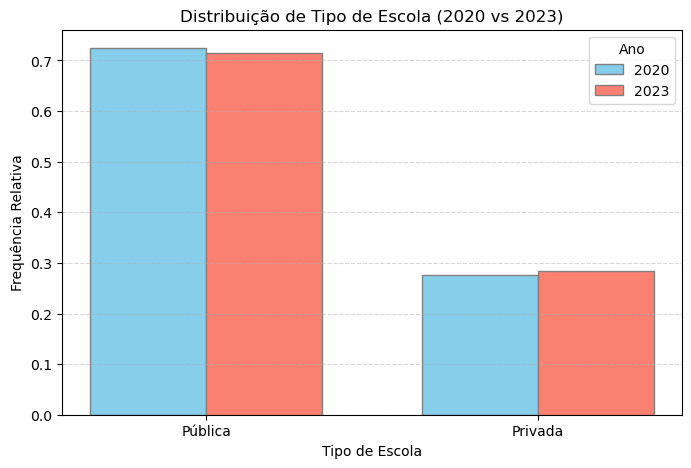

In [26]:
# 1. Preparando os Dados e a Tabela

pct_2020 = (dados2020['tipo_escola'].value_counts(normalize=True) * 100).round(2)
pct_2023 = (dados2023['tipo_escola'].value_counts(normalize=True) * 100).round(2)

tabela_porcentagem = pd.DataFrame({'2020 (%)': pct_2020, '2023 (%)': pct_2023})
display(tabela_porcentagem)

# Pegando a contagem absoluta para o gráfico

cont_2020 = dados2020['tipo_escola'].value_counts(normalize=True)
cont_2023 = dados2023['tipo_escola'].value_counts(normalize=True)


# 2. Configurando o Gráfico

# Pegamos as categorias direto da tabela para garantir que não falta nada
categorias = tabela_porcentagem.index.tolist()

# O SEGREDO ESTÁ AQUI: o reindex alinha os valores exatamente na mesma ordem, 
# e se um ano não tiver alguma categoria, ele preenche com 0!
valores20 = cont_2020.reindex(categorias, fill_value=0).values
valores23 = cont_2023.reindex(categorias, fill_value=0).values

# Definindo parâmetros e posições para as barras agrupadas
largura_barra = 0.35
r1 = np.arange(len(categorias))       
r2 = [x + largura_barra for x in r1]


# 3. Plot do Gráfico

plt.figure(figsize=(8, 5))

# Criando as barras + ajustes
plt.bar(r1, valores20, color='skyblue', width=largura_barra, edgecolor='gray', label='2020')
plt.bar(r2, valores23, color='salmon', width=largura_barra, edgecolor='gray', label='2023')

plt.title('Distribuição de Tipo de Escola (2020 vs 2023)')
plt.ylabel('Frequência Relativa')
plt.xlabel('Tipo de Escola')


# Colocando os nomes das categorias exatamente no meio das duas barras
plt.xticks([r + largura_barra/2 for r in r1], categorias)



plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Ano')

plt.show()


### Interpretação

A análise da distribuição da variável **TP_ESCOLA (Tipo de Escola)** é fundamental para compreender as desigualdades estruturais no acesso ao ensino superior, especialmente para o curso de Direito, que é historicamente de alta concorrência. A literatura educacional aponta que alunos oriundos da rede privada tendem a apresentar um desempenho médio superior (MPE), reflexo direto de maiores investimentos em infraestrutura e metodologias focadas em exames de seleção. 

Ao comparar os anos de 2020 e 2023, buscamos identificar se o choque do ensino remoto emergencial durante a pandemia aprofundou esse abismo, visto que a rede pública enfrentou desafios severos de continuidade pedagógica nesse período. Dessa forma, o "Tipo de Escola" consolida-se como uma variável preditiva (feature) de alto impacto para explicar a variância nas notas dos candidatos.

___

### Análise da variável: Q024 (Computador em Casa) ###

De acordo com o dicionário do ENEM:

- A: Não possui
- B: Sim, 1
- C: Sim, 2
- D: Sim, 3
- E: Sim, 4 ou mais



,2020 (%),2023 (%)
computador,,
1,42.96,36.51
2,12.67,12.17
3,5.07,5.20
4+,2.57,2.78
Não,36.73,43.33


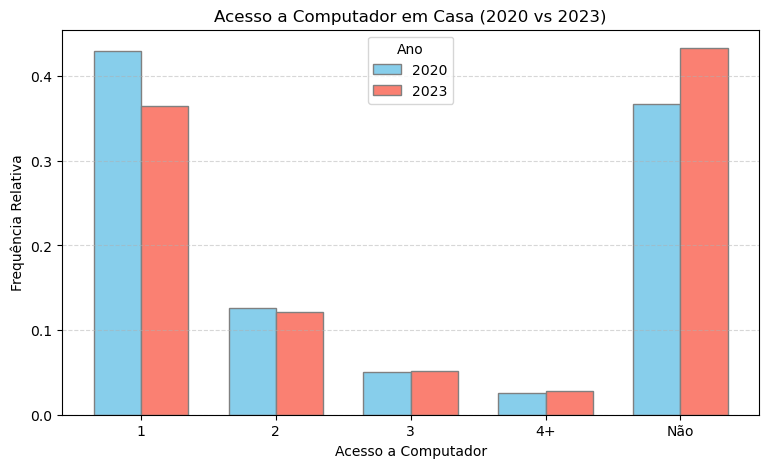

In [27]:
# 1. Preparando os Dados + Tabela

pct_2020_pc = (dados2020['computador'].value_counts(normalize=True) * 100).round(2)
pct_2023_pc = (dados2023['computador'].value_counts(normalize=True) * 100).round(2)

tabela_porcentagem_pc = pd.DataFrame({'2020 (%)': pct_2020_pc, '2023 (%)': pct_2023_pc})
display(tabela_porcentagem_pc)

# Contagem para o gráfico
cont_2020_pc = dados2020['computador'].value_counts(normalize=True)
cont_2023_pc = dados2023['computador'].value_counts(normalize=True)



# 2. Configurando o Gráfico

categorias_pc = tabela_porcentagem_pc.index.tolist()
valores20_pc = cont_2020_pc.reindex(categorias_pc, fill_value=0).values
valores23_pc = cont_2023_pc.reindex(categorias_pc, fill_value=0).values

largura_barra = 0.35
r1_pc = np.arange(len(categorias_pc))
r2_pc = [x + largura_barra for x in r1_pc]



# 3. Plot do Gráfico
plt.figure(figsize=(9, 5))

plt.bar(r1_pc, valores20_pc, color='skyblue', width=largura_barra, edgecolor='gray', label='2020')
plt.bar(r2_pc, valores23_pc, color='salmon', width=largura_barra, edgecolor='gray', label='2023')

plt.title('Acesso a Computador em Casa (2020 vs 2023)')
plt.ylabel('Frequência Relativa')
plt.xlabel('Acesso a Computador')

plt.xticks([r + largura_barra/2 for r in r1_pc], categorias_pc, rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Ano')

plt.show()

### Interpretação

A análise da variável **Q024 (Acesso a Computador em casa)** ganha contornos cruciais nesta Análise Exploratória, sobretudo pela janela temporal escolhida (2020 vs 2023). Durante a pandemia em 2020, a posse de equipamentos tecnológicos deixou de ser apenas um facilitador de estudos para se tornar a condição primária de acesso à educação básica. 

Espera-se que o grupo de candidatos sem acesso a computador apresente uma Média Ponderada (MPE) consideravelmente inferior, refletindo o prejuízo da exclusão digital. Além do viés tecnológico, esta variável atua como um forte *proxy* (indicador indireto) do poder aquisitivo e da infraestrutura domiciliar da família. Observar a evolução temporal dessa posse até 2023 nos ajuda a medir se o retorno ao ensino presencial conseguiu mitigar os danos dessa lacuna tecnológica inicial no desempenho dos vestibulandos de Direito.

___

In [28]:
dados2020['escolaridade_pai'].value_counts()

escolaridade_pai
Ens. Médio Completo    162488
Superior Completo       65548
Fund. II Incompleto     59095
Ens. Médio Incomp.      57525
Fund. I Incompleto      56680
Pós-graduação           48815
Não sei                 35236
Nunca estudou           10482
Name: count, dtype: int64

### Análise da variável: Q001 (Escolaridade do Pai) ###

- A: 'Nunca estudou'
- B: 'Não completou 4ª série/5º ano'
- C: 'Completou 4ª série/5º ano, mas não a 8ª série/9º ano'
- D: 'Completou 8ª série/9º ano, mas não o Ensino Médio'
- E: 'Completou o Ensino Médio, mas não o Ensino Superior'
- F: 'Completou a graduação, mas não a pós-graduação'
- G: 'Completou a pós-graduação'
- H: 'Não sei'



In [29]:
# --- LIMPEZA DOS DADOS ---
df20_pai = dados2020[(dados2020['escolaridade_pai'].notna())]
df23_pai = dados2023[(dados2023['escolaridade_pai'].notna())]

,2020,2023
escolaridade_pai,,
Pós-graduação,9.84%,10.24%
Superior Completo,13.22%,12.44%
Ens. Médio Completo,32.77%,32.56%
Ens. Médio Incomp.,11.60%,11.49%
Fund. II Incompleto,11.92%,11.03%
Fund. I Incompleto,11.43%,10.25%
Não sei,7.11%,9.95%
Nunca estudou,2.11%,2.04%


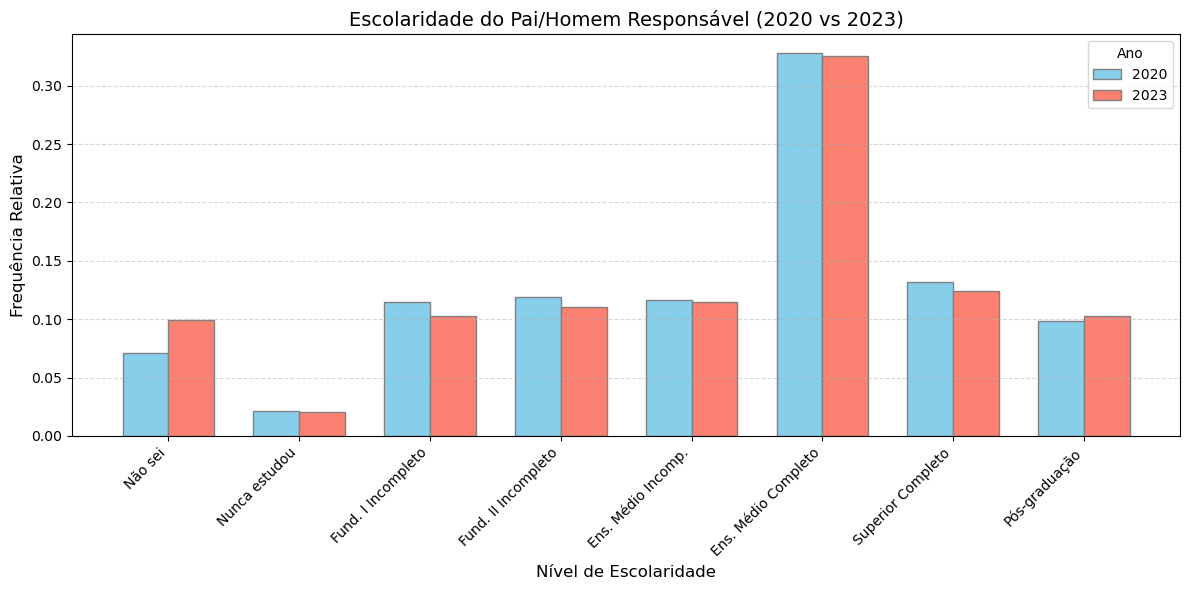

In [30]:
# 1. Tabelas de Frequência (%)

pct_2020_pai = (df20_pai['escolaridade_pai'].value_counts(normalize=True) * 100).round(2)
pct_2023_pai = (df23_pai['escolaridade_pai'].value_counts(normalize=True) * 100).round(2)

ordem = ['Pós-graduação','Superior Completo','Ens. Médio Completo','Ens. Médio Incomp.','Fund. II Incompleto','Fund. I Incompleto','Não sei','Nunca estudou']
display(
pd.concat([
    df20_pai['escolaridade_pai'].value_counts(normalize=True).reindex(ordem),
    df23_pai['escolaridade_pai'].value_counts(normalize=True).reindex(ordem)
], axis=1
).set_axis(['2020', '2023'], axis=1
).fillna(0
).style.format('{:.2%}')
)

# Contagem

cont_2020_pai = df20_pai['escolaridade_pai'].value_counts(normalize=True)
cont_2023_pai = df23_pai['escolaridade_pai'].value_counts(normalize=True)


# 2. Configurando o Gráfico

ordem_categorias = [
    'Não sei',
    'Nunca estudou', 
    'Fund. I Incompleto', 
    'Fund. II Incompleto', 
    'Ens. Médio Incomp.', 
    'Ens. Médio Completo', 
    'Superior Completo', 
    'Pós-graduação',
]


valores20_pai = cont_2020_pai.reindex(ordem_categorias, fill_value=0).values
valores23_pai = cont_2023_pai.reindex(ordem_categorias, fill_value=0).values

largura_barra = 0.35
r1_pai = np.arange(len(ordem_categorias))
r2_pai = [x + largura_barra for x in r1_pai]


# 3. Plot do Gráfico

plt.figure(figsize=(12, 6)) 

plt.bar(r1_pai, valores20_pai, color='skyblue', width=largura_barra, edgecolor='gray', label='2020')
plt.bar(r2_pai, valores23_pai, color='salmon', width=largura_barra, edgecolor='gray', label='2023')

plt.title('Escolaridade do Pai/Homem Responsável (2020 vs 2023)', fontsize=14)
plt.ylabel('Frequência Relativa', fontsize=12)
plt.xlabel('Nível de Escolaridade', fontsize=12)

# Rotação de 45 graus para os textos caberem perfeitamente
plt.xticks([r + largura_barra/2 for r in r1_pai], ordem_categorias, rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Ano')
plt.tight_layout() 

plt.show()

### Interpretação

A variável **Escolaridade do pai** atua como um forte indicativo do nível socioeconômico e do histórico de capital cultural do núcleo familiar. Candidatos com pais que completaram o Ensino Superior ou Pós-graduação tendem a possuir maior acesso a recursos pedagógicos, o que geralmente se reflete em uma Média Ponderada (MPE) mais alta no ENEM.

A resposta “Não sei” pode estar associada a diferentes contextos familiares, como menor convivência com a figura paterna/materna ou desconhecimento sobre sua trajetória educacional. No entanto, não é possível inferir diretamente a ausência dessa figura apenas com base nessa categoria.
___

### Análise da variável: Q002 (Escolaridade da Mãe) ###

- A: 'Nunca estudou'
- B: 'Não completou 4ª série/5º ano'
- C: 'Completou 4ª série/5º ano, mas não a 8ª série/9º ano'
- D: 'Completou 8ª série/9º ano, mas não o Ensino Médio'
- E: 'Completou o Ensino Médio, mas não o Ensino Superior'
- F: 'Completou a graduação, mas não a pós-graduação'
- G: 'Completou a pós-graduação'
- H: 'Não sei'



In [31]:
dados2020['escolaridade_mae'].value_counts()

escolaridade_mae
Ens. Médio Completo    182651
Superior Completo       82449
Pós-graduação           76464
Ens. Médio Incomp.      54686
Fund. II Incompleto     46276
Fund. I Incompleto      36151
Não sei                 11792
Nunca estudou            5400
Name: count, dtype: int64

In [32]:
# --- LIMPEZA DOS DADOS ---

# Filtrando para tirar o "Não sei" e os NaN

df20_mae = dados2020[(dados2020['escolaridade_mae'].notna())]
df23_mae = dados2023[(dados2023['escolaridade_mae'].notna())]

,2020,2023
escolaridade_mae,,
Pós-graduação,15.42%,16.42%
Superior Completo,16.63%,15.87%
Ens. Médio Completo,36.83%,37.24%
Ens. Médio Incomp.,11.03%,11.23%
Fund. II Incompleto,9.33%,8.30%
Fund. I Incompleto,7.29%,6.27%
Nunca estudou,1.09%,1.00%
Não sei,2.38%,3.67%


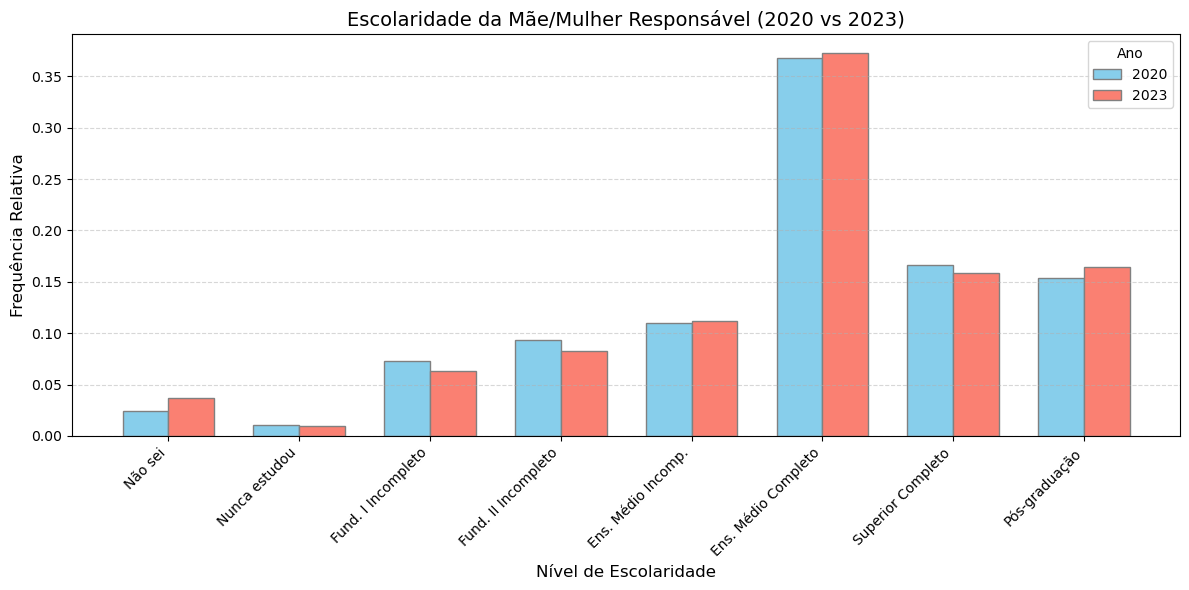

In [33]:
# 1. Tabelas de Frequência (%)
pct_2020_mae = (df20_mae['escolaridade_mae'].value_counts(normalize=True) * 100).round(2)
pct_2023_mae = (df23_mae['escolaridade_mae'].value_counts(normalize=True) * 100).round(2)

ordem = ['Pós-graduação','Superior Completo','Ens. Médio Completo','Ens. Médio Incomp.','Fund. II Incompleto','Fund. I Incompleto','Nunca estudou','Não sei']
display(
pd.concat([
    df20_mae['escolaridade_mae'].value_counts(normalize=True).reindex(ordem),
    df23_mae['escolaridade_mae'].value_counts(normalize=True).reindex(ordem)
], axis=1
).set_axis(['2020', '2023'], axis=1
).fillna(0
).style.format('{:.2%}')
)

# Contagem

cont_2020_mae = df20_mae['escolaridade_mae'].value_counts(normalize=True)
cont_2023_mae = df23_mae['escolaridade_mae'].value_counts(normalize=True)


# 2. Configurando o Gráfico
valores20_mae = cont_2020_mae.reindex(ordem_categorias, fill_value=0).values
valores23_mae = cont_2023_mae.reindex(ordem_categorias, fill_value=0).values

r1_mae = np.arange(len(ordem_categorias))
r2_mae = [x + largura_barra for x in r1_mae]


# 3. Plot do Gráfico
plt.figure(figsize=(12, 6)) 

plt.bar(r1_mae, valores20_mae, color='skyblue', width=largura_barra, edgecolor='gray', label='2020')
plt.bar(r2_mae, valores23_mae, color='salmon', width=largura_barra, edgecolor='gray', label='2023')

plt.title('Escolaridade da Mãe/Mulher Responsável (2020 vs 2023)', fontsize=14)
plt.ylabel('Frequência Relativa', fontsize=12)
plt.xlabel('Nível de Escolaridade', fontsize=12)

plt.xticks([r + largura_barra/2 for r in r1_mae], ordem_categorias, rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Ano')
plt.tight_layout()

plt.show()

### Interpretação

A variável **Escolaridade da mãe** é amplamente apontada por especialistas em demografia da educação como o preditor individual mais forte do desempenho acadêmico de um estudante. Assim como na análise paterna, as respostas "Não sei" foram filtradas para garantir a precisão da correlação linear com a nota final.

A presença de mães com Ensino Superior completo em uma residência altera drasticamente a dinâmica de incentivo aos estudos dos filhos. Ao analisar esta feature comparando 2020 e 2023, busca-se identificar se a vantagem competitiva garantida pelo alto grau de instrução materno se acentuou ou se reduziu com o retorno pleno do ensino presencial no Brasil.
___

### Análise da variável: Q003 (Ocupação do Pai) e Q004 (Ocupação da Mãe)

- A (*Grupo 1*): Lavrador, agricultor sem empregados, bóia fria, criador de animais (gado, porcos, galinhas, ovelhas, cavalos etc.), apicultor, pescador, lenhador, seringueiro, extrativista. 

- B (*Grupo 2*): Diarista, empregado doméstico, cuidador de idosos, babá, cozinheiro (em casas particulares), motorista particular, jardineiro, faxineiro de empresas e prédios, vigilante, porteiro, carteiro, office-boy, vendedor, caixa, atendente de loja, auxiliar administrativo, recepcionista, servente de pedreiro, repositor de mercadoria.

- c (*Grupo 3*): Padeiro, cozinheiro industrial ou em restaurantes, sapateiro, costureiro, joalheiro, torneiro mecânico, operador de máquinas, soldador, operário de fábrica, trabalhador da mineração, pedreiro, pintor, eletricista, encanador, motorista, caminhoneiro, taxista.

- D (*Grupo 4*): Professor (de ensino fundamental ou médio, idioma, música, artes etc.), técnico (de enfermagem, contabilidade, eletrônica etc.), policial, militar de baixa patente (soldado, cabo, sargento), corretor de imóveis, supervisor, gerente, mestre de obras, pastor, microempresário (proprietário de empresa com menos de 10 empregados), pequeno comerciante, pequeno proprietário de terras, trabalhador autônomo ou por conta própria.

- E (*Grupo 5*): Médico, engenheiro, dentista, psicólogo, economista, advogado, juiz, promotor, defensor, delegado, tenente, capitão, coronel, professor universitário, diretor em empresas públicas ou privadas, político, proprietário de empresas com mais de 10 empregados.

- F (*Não sei*)


In [34]:
ordem = ['Não sei','Grupo 1','Grupo 2','Grupo 3','Grupo 4','Grupo 5']
pd.concat([
    dados2020.rename(columns={'grupo_social_1':'Trabalho do pai/homem resp.'})['Trabalho do pai/homem resp.'].value_counts(normalize=True).reindex(ordem),
    dados2023.rename(columns={'grupo_social_1':'Trabalho do pai/homem resp.'})['Trabalho do pai/homem resp.'].value_counts(normalize=True).reindex(ordem)
], axis=1
).set_axis(['2020', '2023'], axis=1
).fillna(0
).style.format('{:.2%}')

,2020,2023
Trabalho do pai/homem resp.,,
Não sei,9.61%,11.67%
Grupo 1,12.95%,12.93%
Grupo 2,17.79%,17.30%
Grupo 3,21.95%,22.85%
Grupo 4,26.96%,24.41%
Grupo 5,10.74%,10.83%


In [35]:
pd.concat([
    dados2020.rename(columns={'grupo_social_2':'Trabalho da mãe/mulher resp.'})['Trabalho da mãe/mulher resp.'].value_counts(normalize=True).reindex(ordem),
    dados2023.rename(columns={'grupo_social_2':'Trabalho da mãe/mulher resp.'})['Trabalho da mãe/mulher resp.'].value_counts(normalize=True).reindex(ordem)
], axis=1
).set_axis(['2020', '2023'], axis=1
).fillna(0
).style.format('{:.2%}')

,2020,2023
Trabalho da mãe/mulher resp.,,
Não sei,8.11%,9.16%
Grupo 1,10.09%,10.04%
Grupo 2,36.38%,36.03%
Grupo 3,6.22%,6.51%
Grupo 4,31.36%,30.11%
Grupo 5,7.84%,8.16%


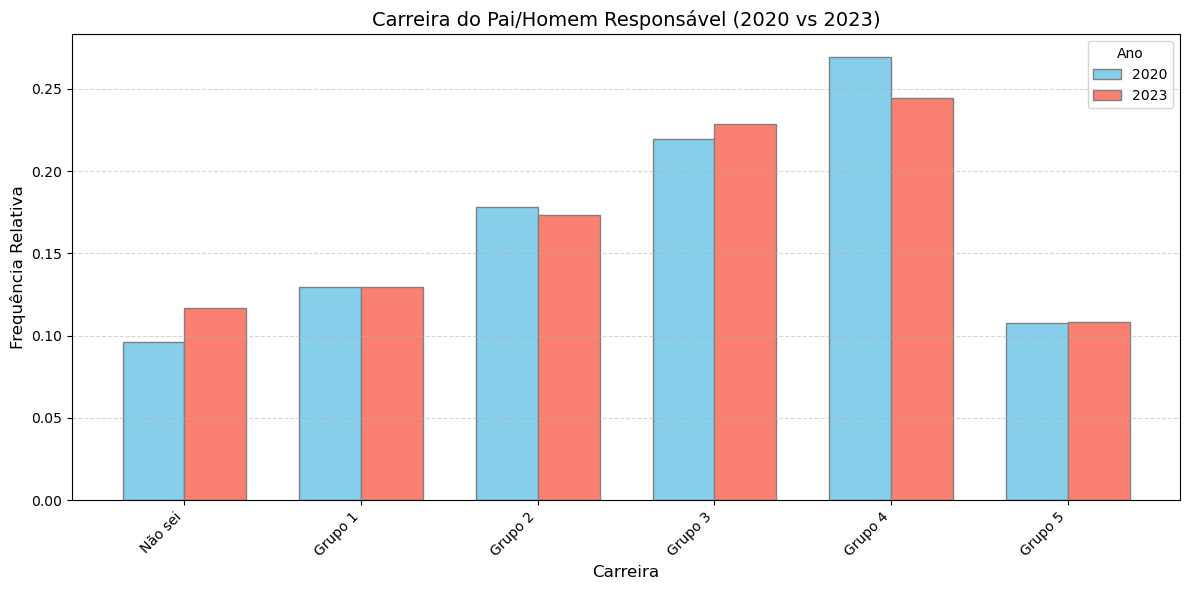

In [36]:
cont_2020_pai = dados2020['grupo_social_1'].value_counts(normalize=True).reindex(ordem, fill_value=0).values
cont_2023_pai = dados2023['grupo_social_1'].value_counts(normalize=True).reindex(ordem, fill_value=0).values

ordem = ['Não sei','Grupo 1','Grupo 2','Grupo 3','Grupo 4','Grupo 5']

largura_barra = 0.35
r1_pai = np.arange(len(ordem))
r2_pai = [x + largura_barra for x in r1_pai]


# Plot do Gráfico


plt.figure(figsize=(12, 6)) 

plt.bar(r1_pai, cont_2020_pai, color='skyblue', width=largura_barra, edgecolor='gray', label='2020')
plt.bar(r2_pai, cont_2023_pai, color='salmon', width=largura_barra, edgecolor='gray', label='2023')

plt.title('Carreira do Pai/Homem Responsável (2020 vs 2023)', fontsize=14)
plt.ylabel('Frequência Relativa', fontsize=12)
plt.xlabel('Carreira', fontsize=12)

# Rotação de 45 graus para os textos caberem perfeitamente
plt.xticks([r + largura_barra/2 for r in r1_pai], ordem, rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Ano')
plt.tight_layout() 

plt.show()

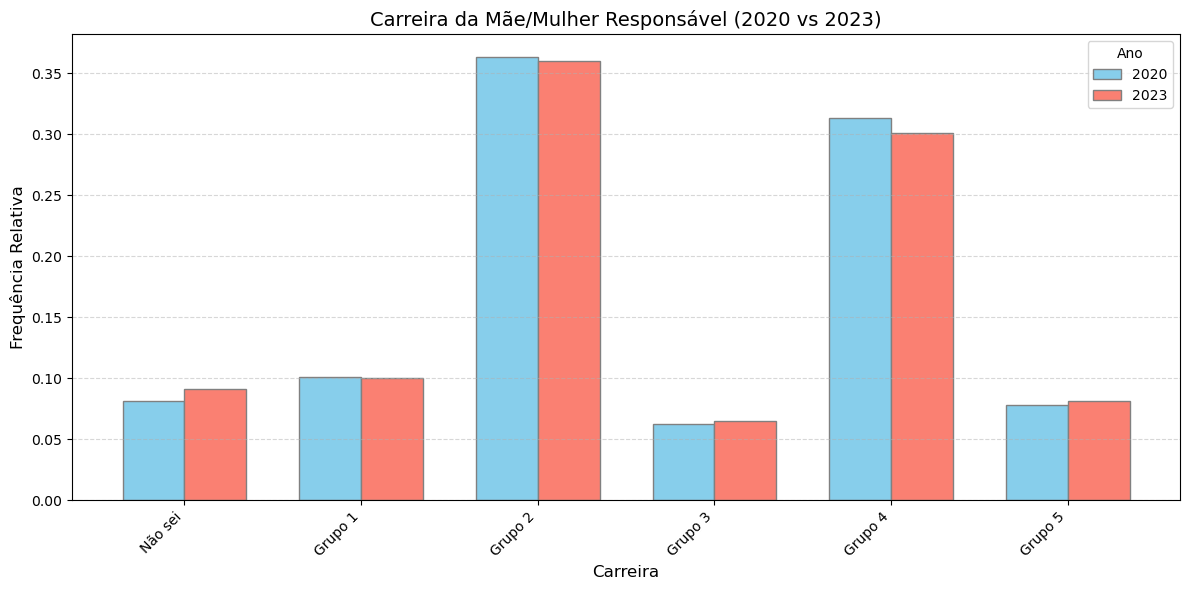

In [37]:
cont_2020_mae = dados2020['grupo_social_2'].value_counts(normalize=True).reindex(ordem, fill_value=0).values
cont_2023_mae = dados2023['grupo_social_2'].value_counts(normalize=True).reindex(ordem, fill_value=0).values

largura_barra = 0.35
r1_mae = np.arange(len(ordem))
r2_mae = [x + largura_barra for x in r1_pai]


# Plot do Gráfico

cat = ['Não sei','Grupo 1','Grupo 2','Grupo 3','Grupo 4','Grupo 5']

plt.figure(figsize=(12, 6)) 

plt.bar(r1_mae, cont_2020_mae, color='skyblue', width=largura_barra, edgecolor='gray', label='2020')
plt.bar(r2_mae, cont_2023_mae, color='salmon', width=largura_barra, edgecolor='gray', label='2023')

plt.title('Carreira da Mãe/Mulher Responsável (2020 vs 2023)', fontsize=14)
plt.ylabel('Frequência Relativa', fontsize=12)
plt.xlabel('Carreira', fontsize=12)

# Rotação de 45 graus para os textos caberem perfeitamente
plt.xticks([r + largura_barra/2 for r in r1_pai], cat, rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Ano')
plt.tight_layout() 

plt.show()

### Interpretação:

A análise conjunta da ocupação do pai (Q003) e da mãe (Q004) amplia a compreensão da inserção socioeconômica familiar, permitindo avaliar de forma mais completa o capital social disponível aos candidatos. Em ambos os casos, observa-se concentração nos grupos intermediários, especialmente nos Grupos 3 (padeiro, cozinheiro, sapateiro) e 4 (professor, técnico, policial) para os pais e Grupos 2 (diarista, doméstica, porteira) e 4 (professora, técnica, policial) para as mães, indicando predominância de famílias inseridas em atividades técnicas, industriais e de serviços.

No entanto, há diferenças relevantes entre os perfis. Enquanto a ocupação paterna apresenta maior presença nos Grupos 3 e 4, sugerindo inserção em atividades técnicas e industriais com maior estabilidade, a ocupação materna concentra-se mais fortemente no Grupo 2, associado a serviços operacionais. Essa diferença pode sugerir desigualdades estruturais no mercado de trabalho, especialmente no acesso feminino a ocupações de maior status e remuneração.

A comparação entre 2020 e 2023 revela relativa estabilidade na distribuição para ambos, com crescimento geral em todos os grupos. Esse movimento pode estar associado à recuperação das condições socioeconômicas após a pandemia de 2020, bem como ao aumento da escolaridade das mães observado em Q002, que pode contribuir para maior inserção em ocupações de maior qualificação.

Apesar da presença nos grupos superiores, sendo eles os grupos 4 e 5 (médico/a, engenheiro/a, empresário/a), a concentração nos grupos intermediários pode insinuar que o perfil socioeconômico dos candidatos ao curso de Direito está associado a níveis moderados a elevados de capital social.

___

### Análise da variável: Tipo de Sexo

De acordo com o dicionário do ENEM:

M: Masculino

F: Feminino

In [38]:

contagem_2020 = dados2020['sexo'].value_counts()
contagem_2023 = dados2023['sexo'].value_counts()

# Porcentagem
perc_2020 = dados2020['sexo'].value_counts(normalize=True) * 100
perc_2023 = dados2023['sexo'].value_counts(normalize=True) * 100

# Tabela
tabela_sexo = pd.DataFrame({
    '% 2020': perc_2020.round(2),
    '% 2023': perc_2023.round(2)
})

display(tabela_sexo)

,% 2020,% 2023
sexo,,
F,55.78,55.75
M,44.22,44.25


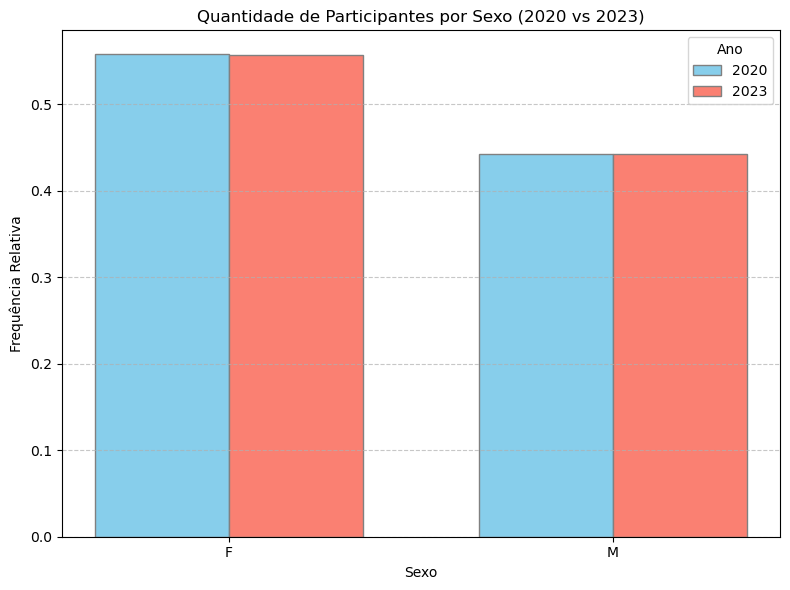

In [39]:
# Frequência absoluta
freq_2020 = dados2020['sexo'].value_counts(normalize=True)
freq_2023 = dados2023['sexo'].value_counts(normalize=True)

# Garantir mesma ordem
categorias = freq_2020.index.tolist()
contagens_20 = freq_2020.reindex(categorias, fill_value=0).values
contagens_23 = freq_2023.reindex(categorias, fill_value=0).values

# Barras agrupadas
bar_width = 0.35
r1 = np.arange(len(categorias))
r2 = [x + bar_width for x in r1]

plt.figure(figsize=(8,6))

plt.bar(r1, contagens_20, color='skyblue', width=bar_width, edgecolor='grey', label='2020')
plt.bar(r2, contagens_23, color='salmon', width=bar_width, edgecolor='grey', label='2023')

plt.xticks([r + bar_width/2 for r in r1], categorias)

plt.title('Quantidade de Participantes por Sexo (2020 vs 2023)')
plt.xlabel('Sexo')
plt.ylabel('Frequência Relativa')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Ano')

plt.tight_layout()
plt.show()

### Interpretação

A educação não é neutra e a partir e a analise de gênero é um uma fas features que auxilia identificar se o genêro é um marcador do grupo majoritario a prestar ao Enem, diante disso é possivel evidenciar a majoritária  estabilidade do genêro feminino durante o ano de 2020 e 2023, portanto, o genêro femino presta mais o curso de Direito em relação ao genêro masculino.

___

### Analise da Variável - Raça/ Cor

De acordo com o dicionário do ENEM:

0. Nao Declarado
1. Branca
2. Preta
3. Parda
4. Amarela
5. Indigena

,% 2020,% 2023
cor_raca,,
Branca,46.60,49.73
Parda,40.15,38.11
Preta,8.86,9.29
Amarela,2.02,1.37
Não declarado,1.95,1.07
Indígena,0.42,0.42


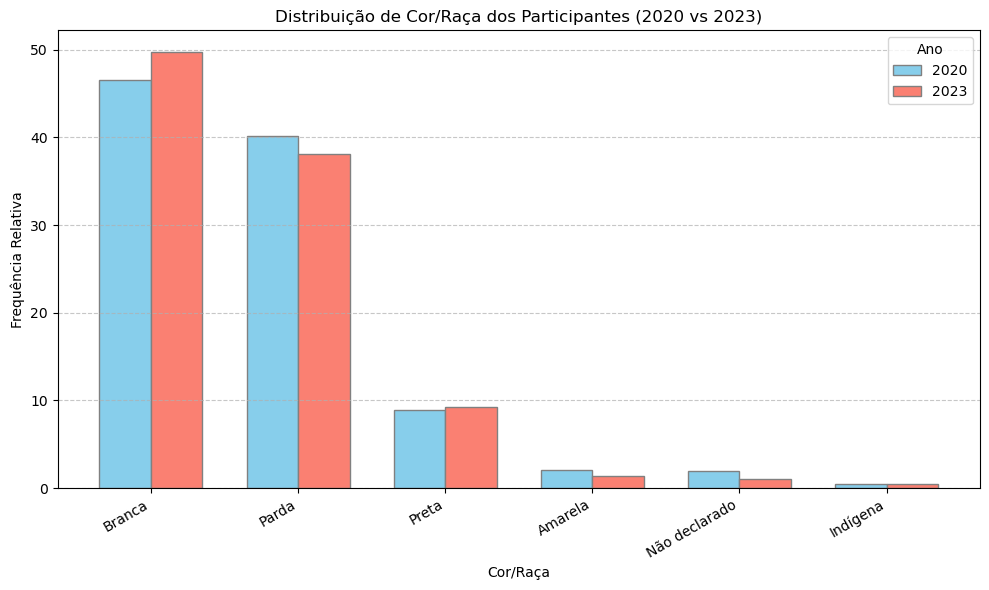

In [40]:
perc_raca_2020 = dados2020['cor_raca'].value_counts(normalize=True) * 100
perc_raca_2023 = dados2023['cor_raca'].value_counts(normalize=True) * 100


# 1 - Tabela comparativa

tabela_raca = pd.DataFrame({
    '% 2020': perc_raca_2020,
    '% 2023': perc_raca_2023
}).fillna(0)


tabela_raca = tabela_raca.sort_values(by='% 2020', ascending=False)

display(tabela_raca.round(2))


# 2 - Preparando gráfico

categorias = tabela_raca.index.tolist()
contagens_20 = tabela_raca['% 2020'].values
contagens_23 = tabela_raca['% 2023'].values

bar_width = 0.35
r1 = np.arange(len(categorias))
r2 = r1 + bar_width


# 3 - Plotando gráfico

plt.figure(figsize=(10,6))

plt.bar(r1, contagens_20, width=bar_width, color='skyblue', edgecolor='grey', label='2020')
plt.bar(r2, contagens_23, width=bar_width, color='salmon', edgecolor='grey', label='2023')

plt.xticks(r1 + bar_width/2, categorias, rotation=30, ha='right')

plt.title('Distribuição de Cor/Raça dos Participantes (2020 vs 2023)')
plt.xlabel('Cor/Raça')
plt.ylabel('Frequência Relativa')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Ano')

plt.tight_layout()
plt.show()

### Interpretação 

A análise da variável cor/raça é fundamental para compreender a diversidade e a desigualdade racial no curso de Direito, na qual grupos que majoritariamente se autodeclaram brancos assumem maior concentração na realização do enem, comprovando que o acesso a educação, no caso a prova do ENEM  se concentra ao grupo historicamente privilegiado na socieda brasileira.

___

### Analise da Variável - Acesso à Internet (Q025)



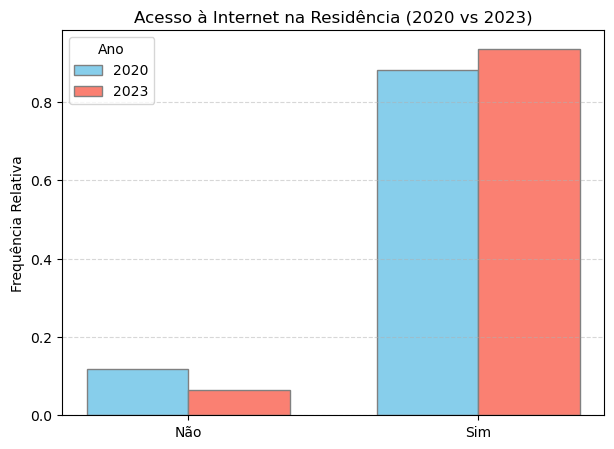

In [41]:
#Tirando os Nan

df20_net = dados2020[dados2020['internet'].notna()]
df23_net = dados2023[dados2023['internet'].notna()]

#Value Counts

cont_2020_net = df20_net['internet'].value_counts(normalize=True)
cont_2023_net = df23_net['internet'].value_counts(normalize=True)

# Plot do Gráfico

ordem_net = ['Não', 'Sim'] # Forçando a ordem lógica
valores20_net = cont_2020_net.reindex(ordem_net, fill_value=0).values
valores23_net = cont_2023_net.reindex(ordem_net, fill_value=0).values

largura_barra = 0.35
r1_net = np.arange(len(ordem_net))
r2_net = [x + largura_barra for x in r1_net]

plt.figure(figsize=(7, 5))
plt.bar(r1_net, valores20_net, color='skyblue', width=largura_barra, edgecolor='gray', label='2020')
plt.bar(r2_net, valores23_net, color='salmon', width=largura_barra, edgecolor='gray', label='2023')

plt.title('Acesso à Internet na Residência (2020 vs 2023)')
plt.ylabel('Frequência Relativa')
plt.xticks([r + largura_barra/2 for r in r1_net], ordem_net)
plt.legend(title='Ano')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Interpretação 

A presença de acesso à internet em casa transcendeu o status de "ferramenta extra" para se tornar um pré-requisito fundamental na preparação para o ENEM. Na edição de 2020, fortemente marcada pela pandemia de COVID-19 e pelo ensino remoto emergencial, a ausência de internet representou uma barreira quase intransponível, isolando completamente o candidato do conteúdo acadêmico. 

Ao observarmos a transição para 2023, analisamos se a exclusão digital severa diminuiu na base de inscritos. Para o curso de Direito, que exige altíssima capacidade de leitura e atualização constante.


___

### Analise da Variável - Localização da Escola (TP_LOCALIZACAO_ESC)

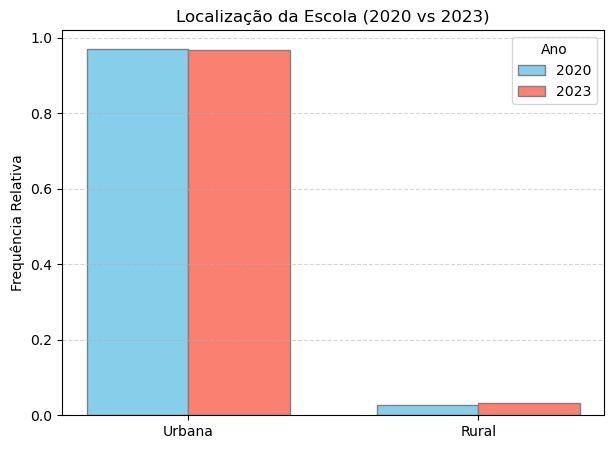

In [42]:
# Tirando os Nan

df20_loc = dados2020[dados2020['localizacao'].notna()]
df23_loc = dados2023[dados2023['localizacao'].notna()]




cont_2020_loc = df20_loc['localizacao'].value_counts(normalize=True)
cont_2023_loc = df23_loc['localizacao'].value_counts(normalize=True)

ordem_loc = ['Urbana', 'Rural']
valores20_loc = cont_2020_loc.reindex(ordem_loc, fill_value=0).values
valores23_loc = cont_2023_loc.reindex(ordem_loc, fill_value=0).values

r1_loc = np.arange(len(ordem_loc))
r2_loc = [x + largura_barra for x in r1_loc]

plt.figure(figsize=(7, 5))
plt.bar(r1_loc, valores20_loc, color='skyblue', width=largura_barra, edgecolor='gray', label='2020')
plt.bar(r2_loc, valores23_loc, color='salmon', width=largura_barra, edgecolor='gray', label='2023')

plt.title('Localização da Escola (2020 vs 2023)')
plt.ylabel('Frequência Relativa')
plt.xticks([r + largura_barra/2 for r in r1_loc], ordem_loc)
plt.legend(title='Ano')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Interpretação 

A localização da escola em que o candidato concluiu (ou está concluindo) o Ensino Médio é um forte indicativo do ecossistema educacional ao seu redor. Escolas urbanas geralmente estão inseridas em áreas com maior acesso a infraestrutura, bibliotecas, cursinhos pré-vestibulares e internet de banda larga. Por outro lado, estudantes de escolas rurais frequentemente enfrentam desafios logísticos, menor disponibilidade de professores especialistas e menor carga horária efetiva.

Historicamente, a esmagadora maioria dos ingressantes em cursos de alta concorrência como o Direito provém de áreas urbanas. O acompanhamento deste cenário entre 2020 e 2023 nos permite verificar se políticas públicas de interiorização do ensino e de cotas conseguiram diversificar minimamente a origem geográfica dos candidatos competitivos.

___

### Análise da Variável - Renda Familiar (Q006)

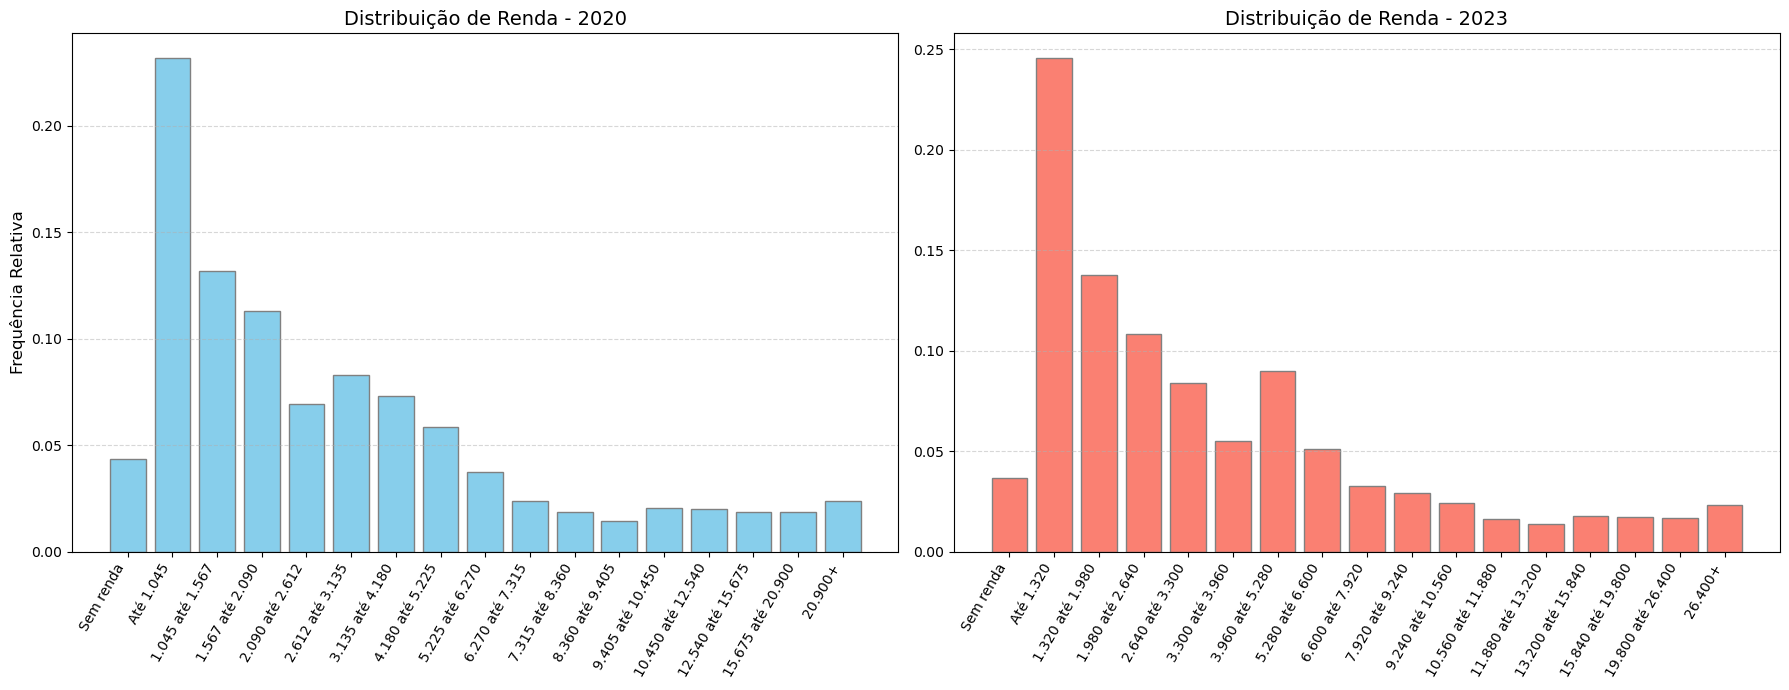

In [43]:
# Tirando os Nan
df20_renda = dados2020[dados2020['renda'].notna()]
df23_renda = dados2023[dados2023['renda'].notna()]



cont_2020_renda = df20_renda['renda'].value_counts(normalize=True)
cont_2023_renda = df23_renda['renda'].value_counts(normalize=True)

ordem_2020 = [
    'Sem renda', 'Até 1.045', '1.045 até 1.567', '1.567 até 2.090', 
    '2.090 até 2.612', '2.612 até 3.135', '3.135 até 4.180', 
    '4.180 até 5.225', '5.225 até 6.270', '6.270 até 7.315', 
    '7.315 até 8.360', '8.360 até 9.405', '9.405 até 10.450', 
    '10.450 até 12.540', '12.540 até 15.675', '15.675 até 20.900', '20.900+'
]

ordem_2023 = [
    'Sem renda', 'Até 1.320', '1.320 até 1.980', '1.980 até 2.640', 
    '2.640 até 3.300', '3.300 até 3.960', '3.960 até 5.280', 
    '5.280 até 6.600', '6.600 até 7.920', '7.920 até 9.240', 
    '9.240 até 10.560', '10.560 até 11.880', '11.880 até 13.200', 
    '13.200 até 15.840', '15.840 até 19.800', '19.800 até 26.400', '26.400+'
]


valores20_renda = cont_2020_renda.reindex(ordem_2020, fill_value=0).values
valores23_renda = cont_2023_renda.reindex(ordem_2023, fill_value=0).values

# Subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico da Esquerda: 2020
ax1.bar(np.arange(len(ordem_2020)), valores20_renda, color='skyblue', edgecolor='gray')
ax1.set_title('Distribuição de Renda - 2020', fontsize=14)
ax1.set_ylabel('Frequência Relativa', fontsize=12)
ax1.set_xticks(np.arange(len(ordem_2020)))
ax1.set_xticklabels(ordem_2020, rotation=60, ha='right') # Rotação 60 para ler bem os números
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Gráfico da Direita: 2023
ax2.bar(np.arange(len(ordem_2023)), valores23_renda, color='salmon', edgecolor='gray')
ax2.set_title('Distribuição de Renda - 2023', fontsize=14)
ax2.set_xticks(np.arange(len(ordem_2023)))
ax2.set_xticklabels(ordem_2023, rotation=60, ha='right')
ax2.grid(axis='y', linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()

### Interpretação 

Junto com a escolaridade materna, a **Renda Familiar** é o preditor socioeconômico mais agressivo no desempenho do ENEM. A renda dita as condições materiais de estudo do candidato: a capacidade de custear colégios privados, materiais didáticos, cursinhos de elite e, fundamentalmente, o "tempo livre" para se dedicar exclusivamente aos estudos sem a necessidade de ingressar precocemente no mercado de trabalho.

A análise foi dividida em dois cenários (2020 e 2023) para respeitar a mudança real nas faixas de salário mínimo declaradas pelos candidatos em cada ano. Para o curso de Direito, espera-se encontrar uma correlação linear forte e positiva: à medida que avançamos para as faixas de renda mais altas no eixo X, a Média Ponderada (MPE) tende a dar saltos significativos, escancarando a elitização do acesso aos cursos de maior prestígio no ensino superior brasileiro.

___

# Variáveis Quantitativas

___

### Análise da Variável - TARGET

,2020,2023
count,495869.00,664852.00
mean,558.19,567.22
std,93.97,91.80
min,140.00,90.42
25%,487.22,501.08
50%,554.16,568.26
75%,627.27,635.61
max,851.55,865.69


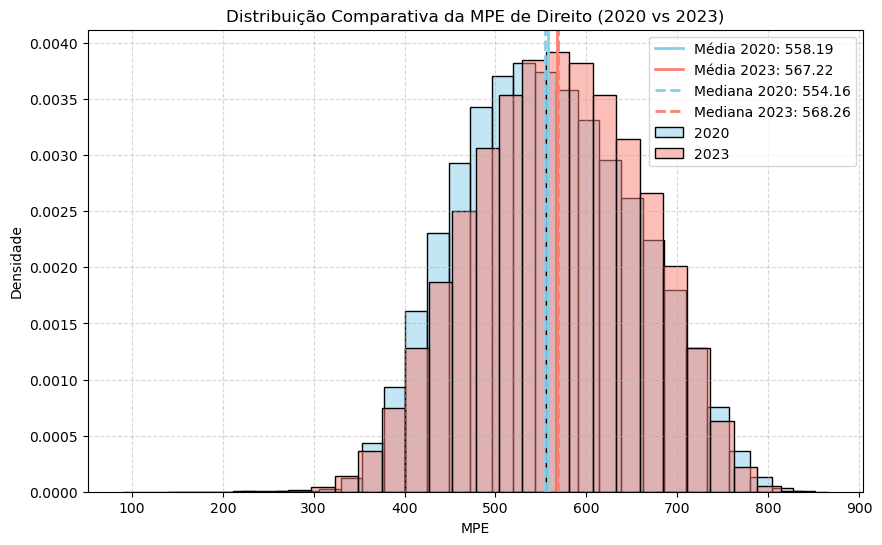

In [44]:
mpe_2020 = dados2020['TARGET'].dropna()
mpe_2023 = dados2023['TARGET'].dropna()

# Criar tabela
tabela = pd.DataFrame({
    '2020': mpe_2020.describe(),
    '2023': mpe_2023.describe()
})

tabela = tabela.round(2)

display(tabela)

## Gráfico MPE
plt.figure(figsize=(10,6))

# 2020
sns.histplot(
    dados2020['TARGET'],
    bins=30,
    stat='density',
    color='skyblue',
    label='2020',
    alpha=0.5
)

# 2023
sns.histplot(
    dados2023['TARGET'],
    bins=30,
    stat='density',
    color='salmon',
    label='2023',
    alpha=0.5
)

plt.xlabel('MPE')
plt.ylabel('Densidade')
plt.title('Distribuição Comparativa da MPE de Direito (2020 vs 2023)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(np.mean(dados2020['TARGET']), color='skyblue', linestyle='-', linewidth=2, label=f'Média 2020: {np.mean(dados2020['TARGET']):.2f}')
plt.axvline(np.mean(dados2023['TARGET']), color='salmon', linestyle='-', linewidth=2, label=f'Média 2023: {np.mean(dados2023['TARGET']):.2f}')
plt.axvline(np.median(dados2020['TARGET']), color='skyblue', linestyle='--', linewidth=2, label=f'Mediana 2020: {np.median(dados2020['TARGET']):.2f}')
plt.axvline(np.median(dados2023['TARGET']), color='salmon', linestyle='--', linewidth=2, label=f'Mediana 2023: {np.median(dados2023['TARGET']):.2f}')
plt.legend()
plt.show()

### Interpretação 

Observa-se um leve aumento no desempenho médio e mediano entre 2020 e 2023, com a distribuição de notas de 2023 apresentando um deslocamento à direita. Apesar disso, as distribuições mantêm formatos semelhantes, indicando que houve uma melhora geral, porém sem mudanças estruturais significativas no padrão de desempenho dos estudantes.

___

### Análise da variavel: NU_NOTA_MT - Nota de Matemática 

,2020,2023
count,495869.00,664852.00
mean,558.19,567.22
std,93.97,91.80
min,140.00,90.42
25%,487.22,501.08
50%,554.16,568.26
75%,627.27,635.61
max,851.55,865.69


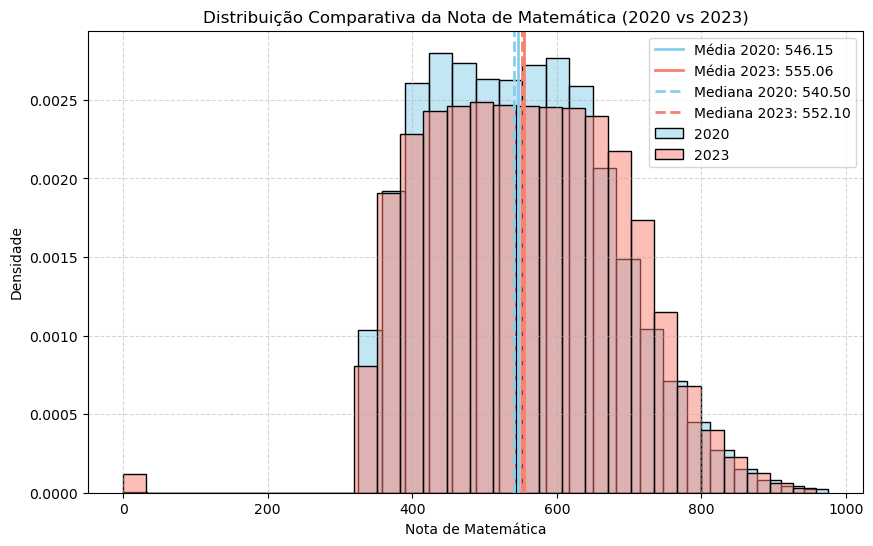

In [45]:
mt_2020 = dados2020['NU_NOTA_MT'].dropna()
mt_2023 = dados2023['NU_NOTA_MT'].dropna()

# Criar tabela 
tabela_mt = pd.DataFrame({
    '2020': mt_2020.describe(),
    '2023': mt_2023.describe()
})

tabela_mt = tabela_mt.round(2)

display(tabela)


## Grafico

plt.figure(figsize=(10,6))

# 2020
sns.histplot(
    dados2020['NU_NOTA_MT'].dropna(),
    bins=30,
    stat='density',
    color='skyblue',
    label='2020',
    alpha=0.5
)

# 2023
sns.histplot(
    dados2023['NU_NOTA_MT'].dropna(),
    bins=30,
    stat='density',
    color='salmon',
    label='2023',
    alpha=0.5
)

plt.xlabel('Nota de Matemática')
plt.ylabel('Densidade')
plt.title('Distribuição Comparativa da Nota de Matemática (2020 vs 2023)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(np.mean(dados2020['NU_NOTA_MT']), color='skyblue', linestyle='-', linewidth=2, label=f'Média 2020: {np.mean(dados2020['NU_NOTA_MT']):.2f}')
plt.axvline(np.mean(dados2023['NU_NOTA_MT']), color='salmon', linestyle='-', linewidth=2, label=f'Média 2023: {np.mean(dados2023['NU_NOTA_MT']):.2f}')
plt.axvline(np.median(dados2020['NU_NOTA_MT']), color='skyblue', linestyle='--', linewidth=2, label=f'Mediana 2020: {np.median(dados2020['NU_NOTA_MT']):.2f}')
plt.axvline(np.median(dados2023['NU_NOTA_MT']), color='salmon', linestyle='--', linewidth=2, label=f'Mediana 2023: {np.median(dados2023['NU_NOTA_MT']):.2f}')
plt.legend()
plt.show()

### Interpretação 

A análise dos dados revela uma mudança perceptível no perfil de desempenho dos candidatos entre os dois períodos, caracterizada por um deslocamento positivo das notas e um aumento na variabilidade dos resultados.

Observa-se um deslocamento da distribuição para a direita em 2023. Na qual indica uma melhora no desempenho geral, confirmada pelo aumento da média que subiu de 546,15 para 555,06 (aumento de aproximadamente 9 pontos).

Em ambos ao anos a média é superior à mediana (50%), o que caracteriza uma cauda a direita , que significa, embora a maior parte dos candidatos esteja concentrada em faixas de notas específicas, existe candidatos as extremidades com notas muito altas que puxa a média para cima. Em 2023, esse fenômeno é mais acentuado, sugerindo um grupo de elite com desempenho ainda superior.

Além disso, gráfico de 2023 exibe uma pequena barra isolada próxima ao valor zero, esse outliers podem representar candidatos que tiveram dificuldades severas com o conteúdo, contrastando drasticamente com a tendência de alta do restante dos candidatos.

Por fim,o  valor máximo em Matemática chega a 958, enquanto na MPE o teto é por volta de 865. Isso reflete o melhor desempenho dos candidatos de direito em  Matemática embora possua uma menor porcentagem de peso no resultado final.

___

### Análise da variavel: NU_NOTA_CN	 - Nota de Ciências da Natureza

,2020,2023
count,495869.00,664852.00
mean,503.72,502.75
std,81.61,85.28
min,0.00,0.00
25%,437.60,446.20
50%,502.90,501.80
75%,565.90,558.50
max,854.80,868.40


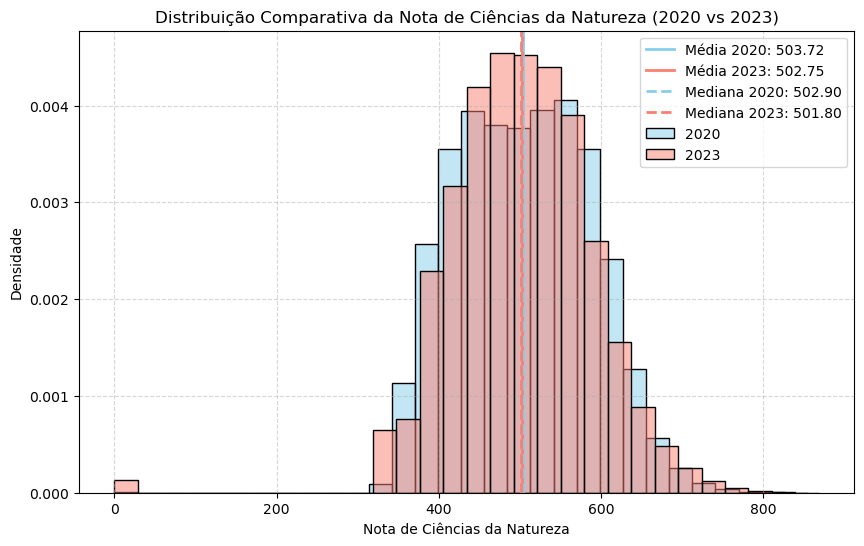

In [46]:
cn_2020 = dados2020['NU_NOTA_CN'].dropna()
cn_2023 = dados2023['NU_NOTA_CN'].dropna()

# Criar tabela 
tabela_cn = pd.DataFrame({
    '2020': cn_2020.describe(),
    '2023': cn_2023.describe()
})

tabela_cn = tabela_cn.round(2)

display(tabela_cn)

plt.figure(figsize=(10,6))

# 2020
sns.histplot(
    dados2020['NU_NOTA_CN'].dropna(),
    bins=30,
    stat='density',
    color='skyblue',
    label='2020',
    alpha=0.5
)

# 2023
sns.histplot(
    dados2023['NU_NOTA_CN'].dropna(),
    bins=30,
    stat='density',
    color='salmon',
    label='2023',
    alpha=0.5
)

plt.xlabel('Nota de Ciências da Natureza')
plt.ylabel('Densidade')
plt.title('Distribuição Comparativa da Nota de Ciências da Natureza (2020 vs 2023)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(np.mean(dados2020['NU_NOTA_CN']), color='skyblue', linestyle='-', linewidth=2, label=f'Média 2020: {np.mean(dados2020['NU_NOTA_CN']):.2f}')
plt.axvline(np.mean(dados2023['NU_NOTA_CN']), color='salmon', linestyle='-', linewidth=2, label=f'Média 2023: {np.mean(dados2023['NU_NOTA_CN']):.2f}')
plt.axvline(np.median(dados2020['NU_NOTA_CN']), color='skyblue', linestyle='--', linewidth=2, label=f'Mediana 2020: {np.median(dados2020['NU_NOTA_CN']):.2f}')
plt.axvline(np.median(dados2023['NU_NOTA_CN']), color='salmon', linestyle='--', linewidth=2, label=f'Mediana 2023: {np.median(dados2023['NU_NOTA_CN']):.2f}')
plt.legend()
plt.show()

### Interpretação 

A distribuição de Ciências da Natureza se aproxima de uma Distribuição Normal, na qual indica uma maior concentração de candidatos em torno na média, houve uma redução sutil, passando de 503,72  em 2020 para 502,75 em 2023. Essa variação de aproximadamente -0,97 pontos indica que o nível de dificuldade percebido ou o desempenho médio dos candidatos permaneceu praticamente o mesmo.

Por outro lado, o desvio padrão aumentou de 81,61 para 85,28, na qual significa que as  notas em 2023 estão mais espalhadas em relação à média. Isso explica por que a curva rosa (2023) no gráfico parece levemente mais larga na base e menos concentrada no pico do que a azul (2020).

Além disso, gráfico de 2023 exibe uma pequena barra isolada próxima ao valor zero, esse outliers podem representar candidatos que tiveram dificuldades severas com o conteúdo, contrastando drasticamente com a tendência de alta do restante dos candidatos.

___

### Análise da variavel: NU_NOTA_CH	- Nota de Ciências Humanas

,2020,2023
count,495869.00,664852.00
mean,529.31,532.20
std,94.68,84.46
min,0.00,0.00
25%,456.50,479.30
50%,534.90,539.70
75%,600.10,591.90
max,862.60,823.00


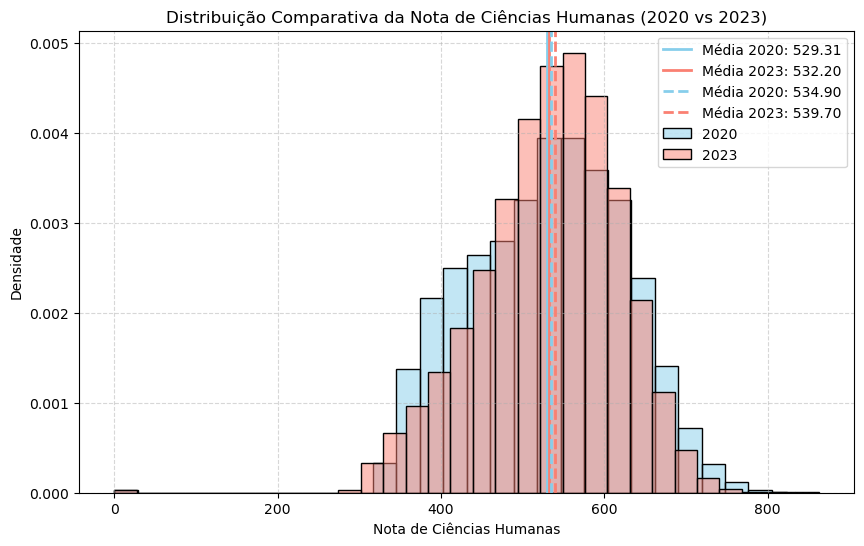

In [47]:
ch_2020 = dados2020['NU_NOTA_CH'].dropna()
ch_2023 = dados2023['NU_NOTA_CH'].dropna()

# Criar tabela 
tabela_ch = pd.DataFrame({
    '2020': ch_2020.describe(),
    '2023': ch_2023.describe()
})

tabela_ch = tabela_ch.round(2)

display(tabela_ch)

# Grafico
plt.figure(figsize=(10,6))

# 2020
sns.histplot(
    dados2020['NU_NOTA_CH'].dropna(),
    bins=30,
    stat='density',
    color='skyblue',
    label='2020',
    alpha=0.5
)

# 2023
sns.histplot(
    dados2023['NU_NOTA_CH'].dropna(),
    bins=30,
    stat='density',
    color='salmon',
    label='2023',
    alpha=0.5
)

plt.xlabel('Nota de Ciências Humanas')
plt.ylabel('Densidade')
plt.title('Distribuição Comparativa da Nota de Ciências Humanas (2020 vs 2023)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(np.mean(dados2020['NU_NOTA_CH']), color='skyblue', linestyle='-', linewidth=2, label=f'Média 2020: {np.mean(dados2020['NU_NOTA_CH']):.2f}')
plt.axvline(np.mean(dados2023['NU_NOTA_CH']), color='salmon', linestyle='-', linewidth=2, label=f'Média 2023: {np.mean(dados2023['NU_NOTA_CH']):.2f}')
plt.axvline(np.median(dados2020['NU_NOTA_CH']), color='skyblue', linestyle='--', linewidth=2, label=f'Média 2020: {np.median(dados2020['NU_NOTA_CH']):.2f}')
plt.axvline(np.median(dados2023['NU_NOTA_CH']), color='salmon', linestyle='--', linewidth=2, label=f'Média 2023: {np.median(dados2023['NU_NOTA_CH']):.2f}')
plt.legend()
plt.show()

### Interpretação 

Na prova de Ciências Humanas em 2023, observou-se que a mediana (539,70) superou a média (532,20), configurando uma assimetria negativa. Diferente do que se possa supor, isso indica que a maioria dos candidatos obteve notas superiores à média, mas o índice geral foi reduzido por um grupo com desempenho muito baixo.

Já o desvio padrao teve uma queda de 94,68 para 84,46 (quase 11%), que é possivel observar no histograma a curva rosa (2023) aumentando e se tornando mais estreita que a azul (2020). Como consequência a  prova de Ciências Humanas em 2023 do curso de Direito, onde esta disciplina possui peso relevante, nesse cenário representa um baixo potencial de diferenciação,como as notas tão agrupadas e próximas, a prova deixa de ser um fator de classificação e passa a ser um critério de consistência, onde qualquer erro mínimo penaliza severamente o candidato em relação à  concorrentes.
___

### Análise da variavel: NU_NOTA_LC	- Nota de Liguagens e Códigos

,2020,2023
count,495869.00,664852.00
mean,538.90,526.82
std,71.63,72.15
min,0.00,0.00
25%,496.40,482.00
50%,546.60,532.40
75%,589.50,577.50
max,783.90,820.80


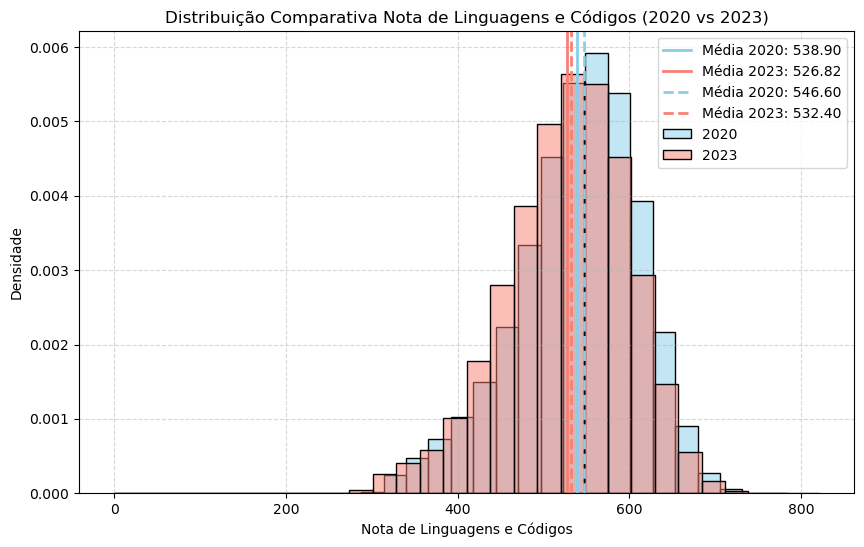

In [48]:
lc_2020 = dados2020['NU_NOTA_LC'].dropna()
lc_2023 = dados2023['NU_NOTA_LC'].dropna()

# Criar tabela 
tabela_lc = pd.DataFrame({
    '2020': lc_2020.describe(),
    '2023': lc_2023.describe()
})

tabela_lc = tabela_lc.round(2)

display(tabela_lc)

# Grafico
plt.figure(figsize=(10,6))

# 2020
sns.histplot(
    dados2020['NU_NOTA_LC'].dropna(),
    bins=30,
    stat='density',
    color='skyblue',
    label='2020',
    alpha=0.5
)

# 2023
sns.histplot(
    dados2023['NU_NOTA_LC'].dropna(),
    bins=30,
    stat='density',
    color='salmon',
    label='2023',
    alpha=0.5
)

plt.xlabel('Nota de Linguagens e Códigos')
plt.ylabel('Densidade')
plt.title('Distribuição Comparativa Nota de Linguagens e Códigos (2020 vs 2023)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(np.mean(dados2020['NU_NOTA_LC']), color='skyblue', linestyle='-', linewidth=2, label=f'Média 2020: {np.mean(dados2020['NU_NOTA_LC']):.2f}')
plt.axvline(np.mean(dados2023['NU_NOTA_LC']), color='salmon', linestyle='-', linewidth=2, label=f'Média 2023: {np.mean(dados2023['NU_NOTA_LC']):.2f}')
plt.axvline(np.median(dados2020['NU_NOTA_LC']), color='skyblue', linestyle='--', linewidth=2, label=f'Média 2020: {np.median(dados2020['NU_NOTA_LC']):.2f}')
plt.axvline(np.median(dados2023['NU_NOTA_LC']), color='salmon', linestyle='--', linewidth=2, label=f'Média 2023: {np.median(dados2023['NU_NOTA_LC']):.2f}')
plt.legend()
plt.show()

### Interpretação 

Na prova de Liguagens a média subiu levemente de 529,31 para 532,20 de 2020 para 2023. No entanto, a mediana (539,70) é significativamente superior à média, na qual denota uma assimetria negativa, indicando que a maior parte dos candidatos obteve notas acima do patamar médio, enquanto um grupo menor, com desempenhos muito baixos, exerceu um peso negativo na curvatura do gráfico, "puxando" a média para baixo.

No histograma, observa-se que a curva de 2023 tornou-se mais estreita e alongada no centro, isso devido a queda de 11% no desvio padrão (de 94,68 para 84,46), na qual é um indicador de que a disciplina está se tornando mais homogênea, isto é, com menor variabilidade notas entre os candidatos.

Por fim,  prova de Ciências Liguagens em 2023 do curso de Direito, onde esta disciplina possui peso relevante, nesse cenário representa um baixo potencial de diferenciação,como as notas tão agrupadas e próximas, a prova deixa de ser um fator de classificação e passa a ser um critério de consistência, onde qualquer erro mínimo penaliza severamente o candidato em relação à  concorrentes.

___

### Análise da variável: NU_NOTA_REDACAO (Nota de Redação)

,2020,2023
count,495869.00,664852.00
mean,630.89,673.86
std,181.17,175.11
min,40.00,40.00
25%,520.00,560.00
50%,620.00,680.00
75%,780.00,820.00
max,1000.00,1000.00


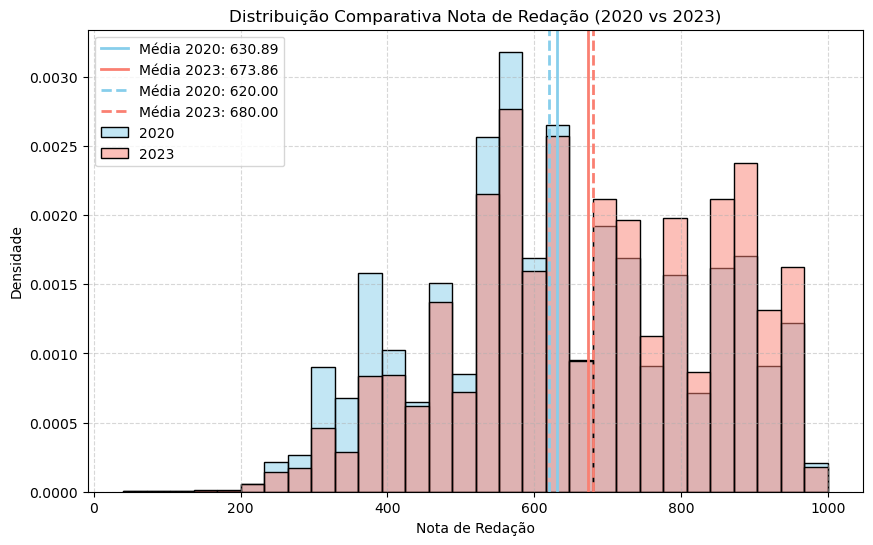

In [49]:
rd_2020 = dados2020['NU_NOTA_REDACAO'].dropna()
rd_2023 = dados2023['NU_NOTA_REDACAO'].dropna()

# Tabela 
tabela_rd = pd.DataFrame({
    '2020': rd_2020.describe(),
    '2023': rd_2023.describe()
})

tabela_rd = tabela_rd.round(2)

display(tabela_rd)

# Grafico
plt.figure(figsize=(10,6))

# 2020
sns.histplot(
    dados2020['NU_NOTA_REDACAO'].dropna(),
    bins=30,
    stat='density',
    color='skyblue',
    label='2020',
    alpha=0.5
)

# 2023
sns.histplot(
    dados2023['NU_NOTA_REDACAO'].dropna(),
    bins=30,
    stat='density',
    color='salmon',
    label='2023',
    alpha=0.5
)

plt.xlabel('Nota de Redação')
plt.ylabel('Densidade')

plt.title('Distribuição Comparativa Nota de Redação (2020 vs 2023)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(np.mean(dados2020['NU_NOTA_REDACAO']), color='skyblue', linestyle='-', linewidth=2, label=f'Média 2020: {np.mean(dados2020['NU_NOTA_REDACAO']):.2f}')
plt.axvline(np.mean(dados2023['NU_NOTA_REDACAO']), color='salmon', linestyle='-', linewidth=2, label=f'Média 2023: {np.mean(dados2023['NU_NOTA_REDACAO']):.2f}')
plt.axvline(np.median(dados2020['NU_NOTA_REDACAO']), color='skyblue', linestyle='--', linewidth=2, label=f'Média 2020: {np.median(dados2020['NU_NOTA_REDACAO']):.2f}')
plt.axvline(np.median(dados2023['NU_NOTA_REDACAO']), color='salmon', linestyle='--', linewidth=2, label=f'Média 2023: {np.median(dados2023['NU_NOTA_REDACAO']):.2f}')
plt.legend()
plt.show()

### Interpretação 

Na prova de Redação há uma grande distribuição de notas, observa-se que há grandes frequências em torno de 600, 800 e 900 pontos. Isso ocorre porque os corretores atribuem notas em blocos, e o nível  para saltar de um patamar para outro (ex: de 720 para 880) é muito bem definido estatisticamente pela rubrica.

As barras rosas (2023) estão em majoritariamente maiores do que as azuis (2020) na faixa de 800 a 950 pontos. Isso indica que em 2023 houve um aumento real.

Diferente de Humanas (onde as notas são espremidas), a Redação mantém um desvio padrão alto (175,11). Isso permite que o candidato de elite, na qual possuem altas notas de redçao abram uma vantagem de quase 200 pontos em relação à média, algo improvável de fazer em Humanas ou Natureza.

Desse modo, em um cenário de alta competitividade como o curso de Direito, a Redação deixa de ser apenas um complemento e consolida-se como o fator determinante na classificação final, sendo a única área capaz de gerar distanciamento real entre os competidores de alto nível.

___

### Análise da variável: IFDM (Índicie firjan de desenvolvimento municipal)

,2020,2023
count,495810.00,664765.00
mean,0.64,0.70
std,0.13,0.12
min,0.16,0.15
25%,0.55,0.62
50%,0.67,0.72
75%,0.74,0.79
max,0.87,0.89


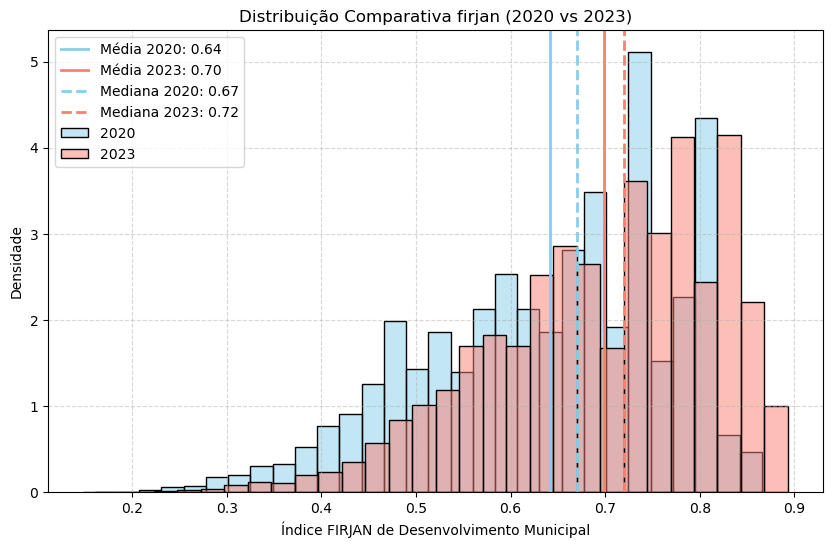

In [50]:
if_2020 = dados2020['IFDM'].dropna()
if_2023 = dados2023['IFDM'].dropna()

# Tabela 
tabela_if = pd.DataFrame({
    '2020': if_2020.describe(),
    '2023': if_2023.describe()
})

tabela_if = tabela_if.round(2)

display(tabela_if)

# Grafico
plt.figure(figsize=(10,6))

# 2020
sns.histplot(
    dados2020['IFDM'].dropna(),
    bins=30,
    stat='density',
    color='skyblue',
    label='2020',
    alpha=0.5
)

# 2023
sns.histplot(
    dados2023['IFDM'].dropna(),
    bins=30,
    stat='density',
    color='salmon',
    label='2023',
    alpha=0.5
)

plt.xlabel('Índice FIRJAN de Desenvolvimento Municipal')
plt.ylabel('Densidade')

plt.title('Distribuição Comparativa firjan (2020 vs 2023)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(np.mean(dados2020['IFDM']), color='skyblue', linestyle='-', linewidth=2, label=f'Média 2020: {np.mean(dados2020['IFDM']):.2f}')
plt.axvline(np.mean(dados2023['IFDM']), color='salmon', linestyle='-', linewidth=2, label=f'Média 2023: {np.mean(dados2023['IFDM']):.2f}')
plt.axvline(0.67, color='skyblue', linestyle='--', linewidth=2, label=f'Mediana 2020: {0.67	}')
plt.axvline(0.72, color='salmon', linestyle='--', linewidth=2, label=f'Mediana 2023: {0.72}')
plt.legend()
plt.show()

### Interpretação 

Observa-se um aumento significativo no Índice FIRJAN de Desenvolvimento Municipal entre 2020 e 2023, com elevação da média, mediana e quartis, além de leve redução da variabilidade. Esse resultado indica uma melhora generalizada nas condições de desenvolvimento dos municípios, o que pode estar associado aos padrões de desempenho educacional observados ao longo da análise.

___

### Análise da variável: PIB_MUNICIPAL_PER_CAPITA

,2020,2023
count,495869.00,664852.00
mean,36738.17,54752.59
std,27602.04,44789.90
min,4920.64,7201.70
25%,20407.26,29205.90
50%,29935.42,44563.38
75%,49122.79,69460.17
max,590594.94,722441.52


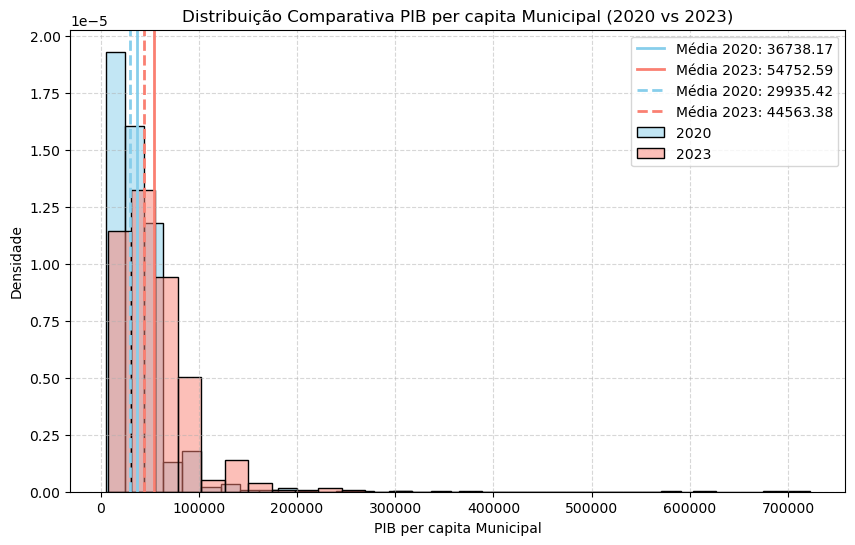

In [51]:
pc_2020 = dados2020['PIB_MUNICIPAL_PER_CAPITA'].dropna()
pc_2023 = dados2023['PIB_MUNICIPAL_PER_CAPITA'].dropna()

# Tabela 
tabela_pc = pd.DataFrame({
    '2020': pc_2020.describe(),
    '2023': pc_2023.describe()
})

tabela_pc = tabela_pc.round(2)

display(tabela_pc)

# Grafico
plt.figure(figsize=(10,6))

# 2020
sns.histplot(
    dados2020['PIB_MUNICIPAL_PER_CAPITA'].dropna(),
    bins=30,
    stat='density',
    color='skyblue',
    label='2020',
    alpha=0.5
)

# 2023
sns.histplot(
    dados2023['PIB_MUNICIPAL_PER_CAPITA'].dropna(),
    bins=30,
    stat='density',
    color='salmon',
    label='2023',
    alpha=0.5
)

plt.xlabel('PIB per capita Municipal')
plt.ylabel('Densidade')

plt.title('Distribuição Comparativa PIB per capita Municipal (2020 vs 2023)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(np.mean(dados2020['PIB_MUNICIPAL_PER_CAPITA']), color='skyblue', linestyle='-', linewidth=2, label=f'Média 2020: {np.mean(dados2020['PIB_MUNICIPAL_PER_CAPITA']):.2f}')
plt.axvline(np.mean(dados2023['PIB_MUNICIPAL_PER_CAPITA']), color='salmon', linestyle='-', linewidth=2, label=f'Média 2023: {np.mean(dados2023['PIB_MUNICIPAL_PER_CAPITA']):.2f}')
plt.axvline(np.median(dados2020['PIB_MUNICIPAL_PER_CAPITA']), color='skyblue', linestyle='--', linewidth=2, label=f'Média 2020: {np.median(dados2020['PIB_MUNICIPAL_PER_CAPITA']):.2f}')
plt.axvline(np.median(dados2023['PIB_MUNICIPAL_PER_CAPITA']), color='salmon', linestyle='--', linewidth=2, label=f'Média 2023: {np.median(dados2023['PIB_MUNICIPAL_PER_CAPITA']):.2f}')
plt.legend()
plt.show()

### Interpretação 

Embora haja crescimento expressivo do PIB per capita entre 2020 e 2023, observa-se também aumento da dispersão, indicando maior desigualdade entre municípios. Esse padrão sugere que o avanço econômico não foi homogêneo, o que pode influenciar de forma desigual as condições educacionais.

___

# CORRELACIONANDO AS VARIÁVEIS QUALITATIVAS COM A TARGET

## Comparando Características das escolas com o Desempenho

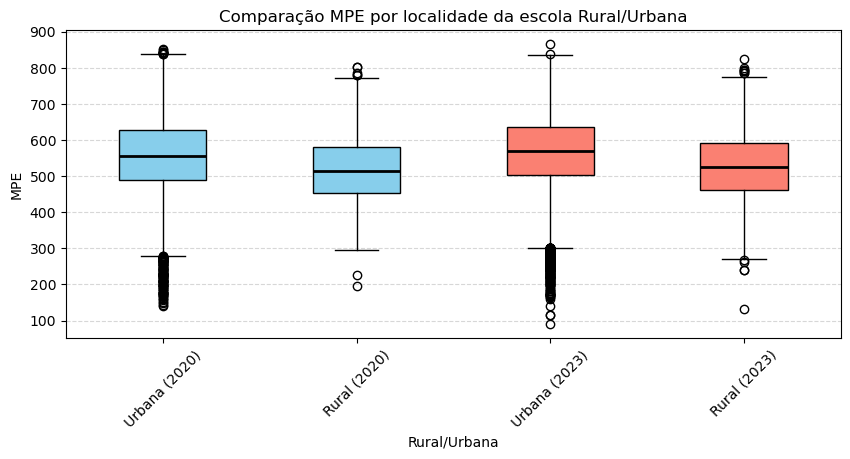

In [52]:
c = ['Urbana', 'Rural']
data = []
labels = []
for i in c:
    grupo_2020 = dados2020.loc[dados2020['localizacao'] == i, 'TARGET']
    data.append(grupo_2020)
    labels.append(f'{i} (2020)')
for i in c:
    grupo_2023 = dados2023.loc[dados2023['localizacao'] == i, 'TARGET']
    data.append(grupo_2023)
    labels.append(f'{i} (2023)')
plt.figure(figsize=(10,4))

box = plt.boxplot(data, patch_artist=True,medianprops=dict(color='black', linewidth=2))
for i, b in enumerate(box['boxes']):
    if i < len(c):  # primeiros = 2020
        b.set_facecolor('skyblue')
    else:           # depois = 2023
        b.set_facecolor('salmon')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(range(1, len(labels)+1), labels, rotation=45)
plt.title('Comparação MPE por localidade da escola Rural/Urbana')
plt.ylabel('MPE')
plt.xlabel('Rural/Urbana')

plt.show()

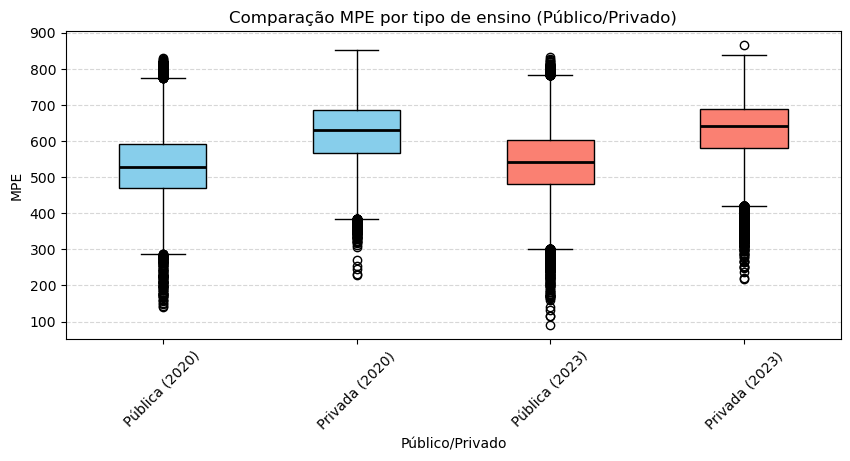

In [53]:
c = ['Pública','Privada']
data = []
labels = []
for i in c:
    grupo_2020 = dados2020.loc[dados2020['tipo_escola'] == i, 'TARGET']
    data.append(grupo_2020)
    labels.append(f'{i} (2020)')
for i in c:
    grupo_2023 = dados2023.loc[dados2023['tipo_escola'] == i, 'TARGET']
    data.append(grupo_2023)
    labels.append(f'{i} (2023)')
plt.figure(figsize=(10,4))

box = plt.boxplot(data, patch_artist=True,medianprops=dict(color='black', linewidth=2))
for i, b in enumerate(box['boxes']):
    if i < len(c):  # primeiros = 2020
        b.set_facecolor('skyblue')
    else:           # depois = 2023
        b.set_facecolor('salmon')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(range(1, len(labels)+1), labels, rotation=45)
plt.title('Comparação MPE por tipo de ensino (Público/Privado)')
plt.ylabel('MPE')
plt.xlabel('Público/Privado')

plt.show()

## Resultado:
A diferença entre as medianas de estudantes de escolas rurais e urbanas sugere uma associação moderada com o desempenho no ENEM, com estudantes de áreas urbanas apresentando, em geral, maiores valores centrais. Estudos indicam que desigualdades educacionais entre campo e cidade estão relacionadas a desafios mais acentuados no meio rural, como maior evasão escolar e menor acesso a recursos educacionais (UBES, Escolas rurais: a importância de garantir educação no campo)

Da mesma forma, observa-se uma diferença consistente entre as medianas de estudantes de escolas públicas e privadas, com desempenho superior entre alunos de escolas privadas em ambos os anos analisados. Essa desigualdade é frequentemente associada a diferenças na qualidade do ensino, infraestrutura e acesso a recursos educacionais, temas amplamente debatidos na literatura sobre educação no Brasil (Extraclasse, Sobre a precarização das escolas públicas, violência e docência)

## Comparando Características dos estudantes com seu desempenho

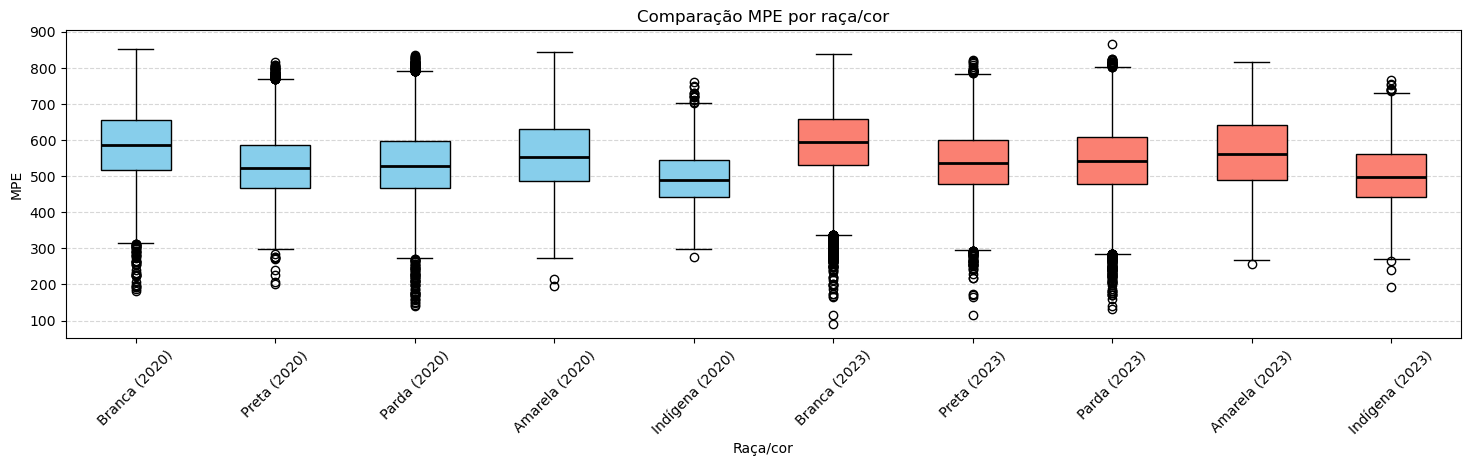

In [54]:
c = ['Branca','Preta','Parda','Amarela','Indígena']
data = []
labels = []
for i in c:
    grupo_2020 = dados2020.loc[dados2020['cor_raca'] == i, 'TARGET']
    data.append(grupo_2020)
    labels.append(f'{i} (2020)')
for i in c:
    grupo_2023 = dados2023.loc[dados2023['cor_raca'] == i, 'TARGET']
    data.append(grupo_2023)
    labels.append(f'{i} (2023)')
plt.figure(figsize=(18,4))

box = plt.boxplot(data, patch_artist=True,medianprops=dict(color='black', linewidth=2))
for i, b in enumerate(box['boxes']):
    if i < len(c):  # primeiros = 2020
        b.set_facecolor('skyblue')
    else:           # depois = 2023
        b.set_facecolor('salmon')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(range(1, len(labels)+1), labels, rotation=45)
plt.title('Comparação MPE por raça/cor')
plt.ylabel('MPE')
plt.xlabel('Raça/cor')

plt.show()

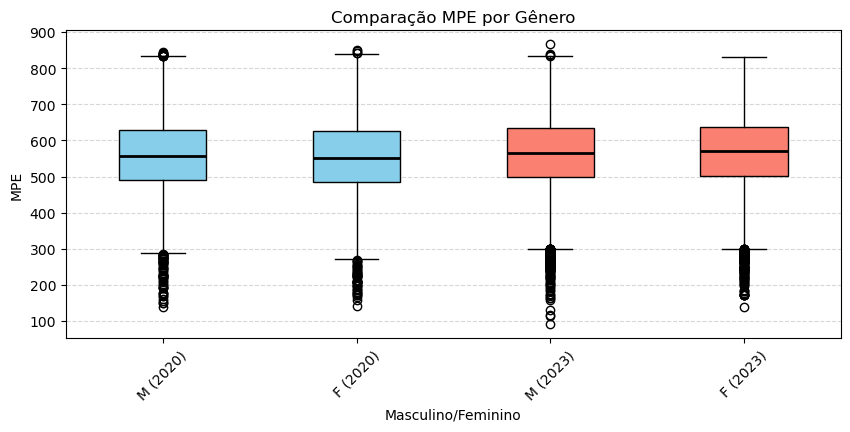

In [55]:
c = ['M','F']
data = []
labels = []
for i in c:
    grupo_2020 = dados2020.loc[dados2020['sexo'] == i, 'TARGET']
    data.append(grupo_2020)
    labels.append(f'{i} (2020)')
for i in c:
    grupo_2023 = dados2023.loc[dados2023['sexo'] == i, 'TARGET']
    data.append(grupo_2023)
    labels.append(f'{i} (2023)')
plt.figure(figsize=(10,4))

box = plt.boxplot(data, patch_artist=True,medianprops=dict(color='black', linewidth=2))
for i, b in enumerate(box['boxes']):
    if i < len(c):  # primeiros = 2020
        b.set_facecolor('skyblue')
    else:           # depois = 2023
        b.set_facecolor('salmon')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(range(1, len(labels)+1), labels, rotation=45)
plt.title('Comparação MPE por Gênero')
plt.ylabel('MPE')
plt.xlabel('Masculino/Feminino')

plt.show()

## Resultado:
Embora existam desafios relacionados ao gênero na educação, a diferença entre as medianas de estudantes masculinos e femininos não parece ser significativa, não indicando uma associação relevante entre gênero e desempenho no ENEM.

Por outro lado, ao analisar os perfis raciais, observam-se diferenças de desempenho entre os grupos, com menores medianas para estudantes pretos, pardos e indígenas. Estudos apontam que desigualdades raciais no Brasil estão associadas a fatores estruturais, como menor acesso a recursos educacionais, renda e oportunidades (Instituto Unibanco, Desigualdade racial na educação brasileira: um guia completo para entender e combater essa realidade). Assim, os padrões observados são consistentes com a literatura.

## Comparando Características familiares e Desempenho

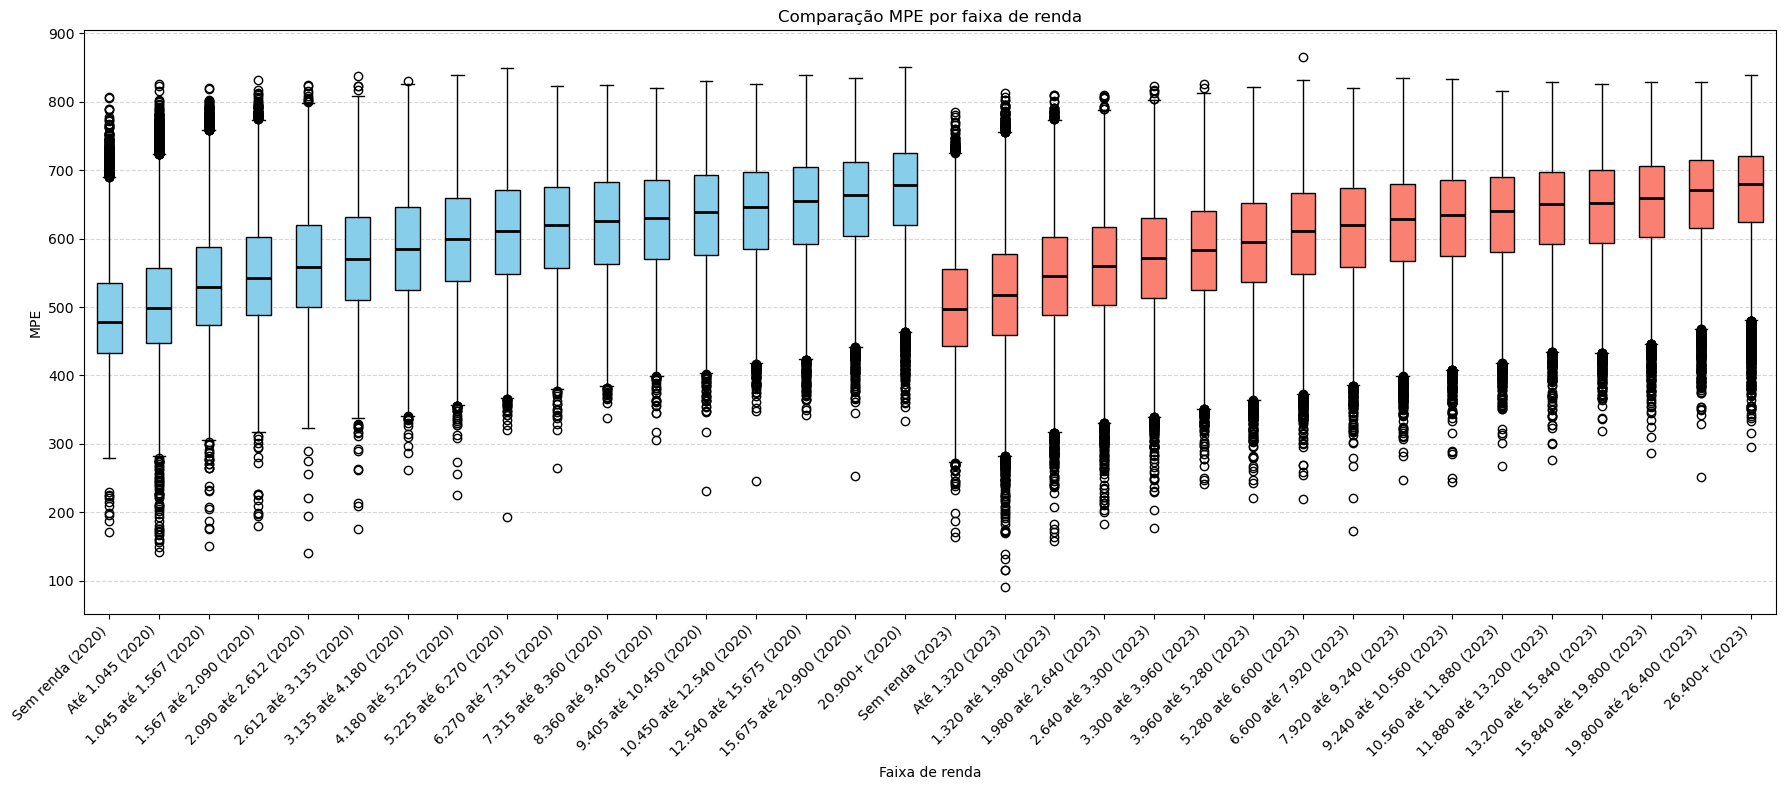

In [56]:
ordem_2020 = [
    'Sem renda', 'Até 1.045', '1.045 até 1.567', '1.567 até 2.090',
    '2.090 até 2.612', '2.612 até 3.135', '3.135 até 4.180',
    '4.180 até 5.225', '5.225 até 6.270', '6.270 até 7.315',
    '7.315 até 8.360', '8.360 até 9.405', '9.405 até 10.450',
    '10.450 até 12.540', '12.540 até 15.675', '15.675 até 20.900', '20.900+'
]

ordem_2023 = [
    'Sem renda', 'Até 1.320', '1.320 até 1.980', '1.980 até 2.640',
    '2.640 até 3.300', '3.300 até 3.960', '3.960 até 5.280',
    '5.280 até 6.600', '6.600 até 7.920', '7.920 até 9.240',
    '9.240 até 10.560', '10.560 até 11.880', '11.880 até 13.200',
    '13.200 até 15.840', '15.840 até 19.800', '19.800 até 26.400', '26.400+'
]

data = []
labels = []

for i in ordem_2020:
    grupo = dados2020.loc[dados2020['renda'] == i, 'TARGET'].dropna()
    if len(grupo) > 0:
        data.append(grupo)
        labels.append(f'{i} (2020)')

for i in ordem_2023:
    grupo = dados2023.loc[dados2023['renda'] == i, 'TARGET'].dropna()
    if len(grupo) > 0:
        data.append(grupo)
        labels.append(f'{i} (2023)')

plt.figure(figsize=(18, 8))

box = plt.boxplot(
    data,
    tick_labels=labels,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)

for i, b in enumerate(box['boxes']):
    if i < sum(len(dados2020.loc[dados2020['renda'] == x, 'TARGET'].dropna()) > 0 for x in ordem_2020):
        b.set_facecolor('skyblue')
    else:
        b.set_facecolor('salmon')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.title('Comparação MPE por faixa de renda')
plt.ylabel('MPE')
plt.xlabel('Faixa de renda')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

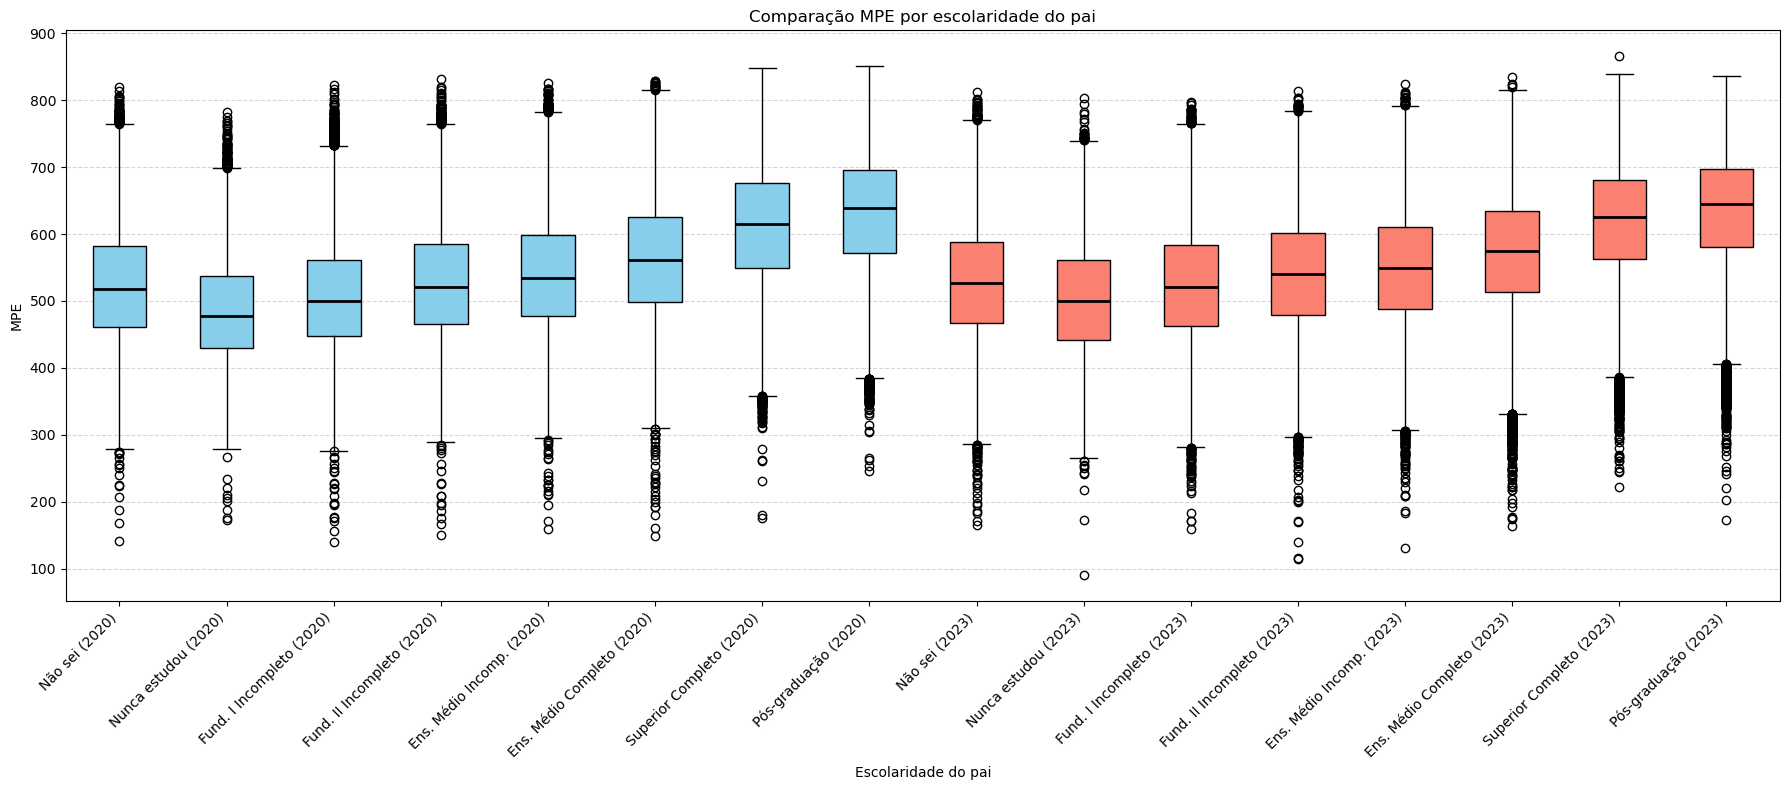

In [57]:
ordem_categorias = [
    'Não sei',
    'Nunca estudou', 
    'Fund. I Incompleto', 
    'Fund. II Incompleto', 
    'Ens. Médio Incomp.', 
    'Ens. Médio Completo', 
    'Superior Completo', 
    'Pós-graduação',
]

data = []
labels = []

for i in ordem_categorias:
    grupo = dados2020.loc[dados2020['escolaridade_pai'] == i, 'TARGET'].dropna()
    if len(grupo) > 0:
        data.append(grupo)
        labels.append(f'{i} (2020)')

for i in ordem_categorias:
    grupo = dados2023.loc[dados2023['escolaridade_pai'] == i, 'TARGET'].dropna()
    if len(grupo) > 0:
        data.append(grupo)
        labels.append(f'{i} (2023)')

plt.figure(figsize=(18, 8))

box = plt.boxplot(
    data,
    tick_labels=labels,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)

for i, b in enumerate(box['boxes']):
    if i < sum(len(dados2020.loc[dados2020['escolaridade_pai'] == x, 'TARGET'].dropna()) > 0 for x in ordem_categorias):
        b.set_facecolor('skyblue')
    else:
        b.set_facecolor('salmon')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.title('Comparação MPE por escolaridade do pai')
plt.ylabel('MPE')
plt.xlabel('Escolaridade do pai')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

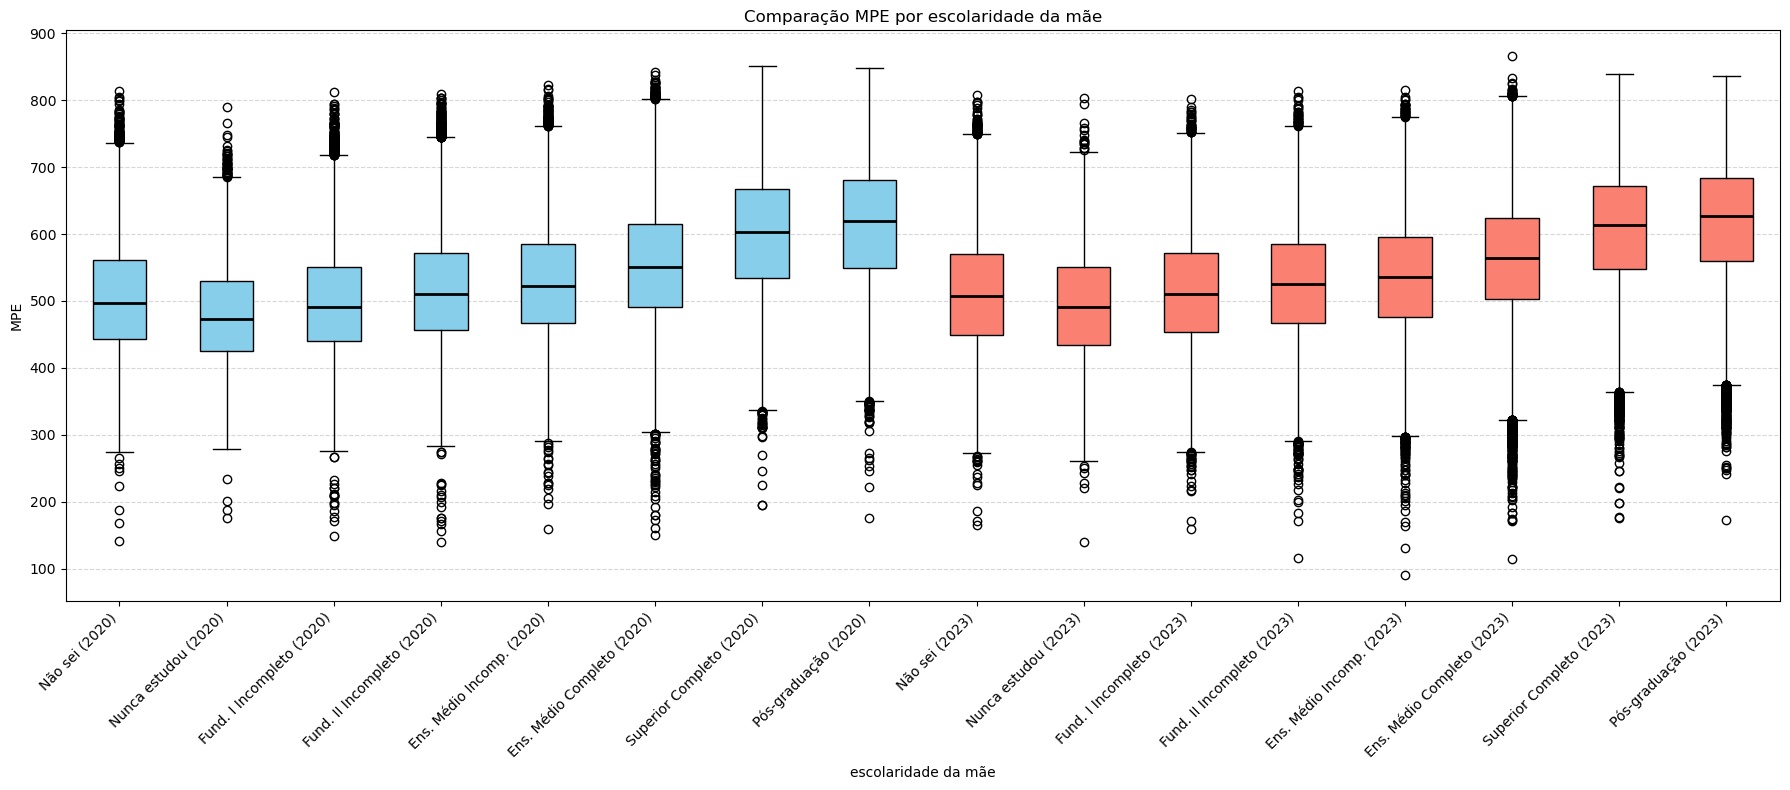

In [58]:
ordem_categorias = [
    'Não sei',
    'Nunca estudou', 
    'Fund. I Incompleto', 
    'Fund. II Incompleto', 
    'Ens. Médio Incomp.', 
    'Ens. Médio Completo', 
    'Superior Completo', 
    'Pós-graduação',
]

data = []
labels = []

for i in ordem_categorias:
    grupo = dados2020.loc[dados2020['escolaridade_mae'] == i, 'TARGET'].dropna()
    if len(grupo) > 0:
        data.append(grupo)
        labels.append(f'{i} (2020)')

for i in ordem_categorias:
    grupo = dados2023.loc[dados2023['escolaridade_mae'] == i, 'TARGET'].dropna()
    if len(grupo) > 0:
        data.append(grupo)
        labels.append(f'{i} (2023)')

plt.figure(figsize=(18, 8))

box = plt.boxplot(
    data,
    tick_labels=labels,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)

for i, b in enumerate(box['boxes']):
    if i < sum(len(dados2020.loc[dados2020['escolaridade_mae'] == x, 'TARGET'].dropna()) > 0 for x in ordem_categorias):
        b.set_facecolor('skyblue')
    else:
        b.set_facecolor('salmon')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.title('Comparação MPE por escolaridade da mãe')
plt.ylabel('MPE')
plt.xlabel('escolaridade da mãe')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

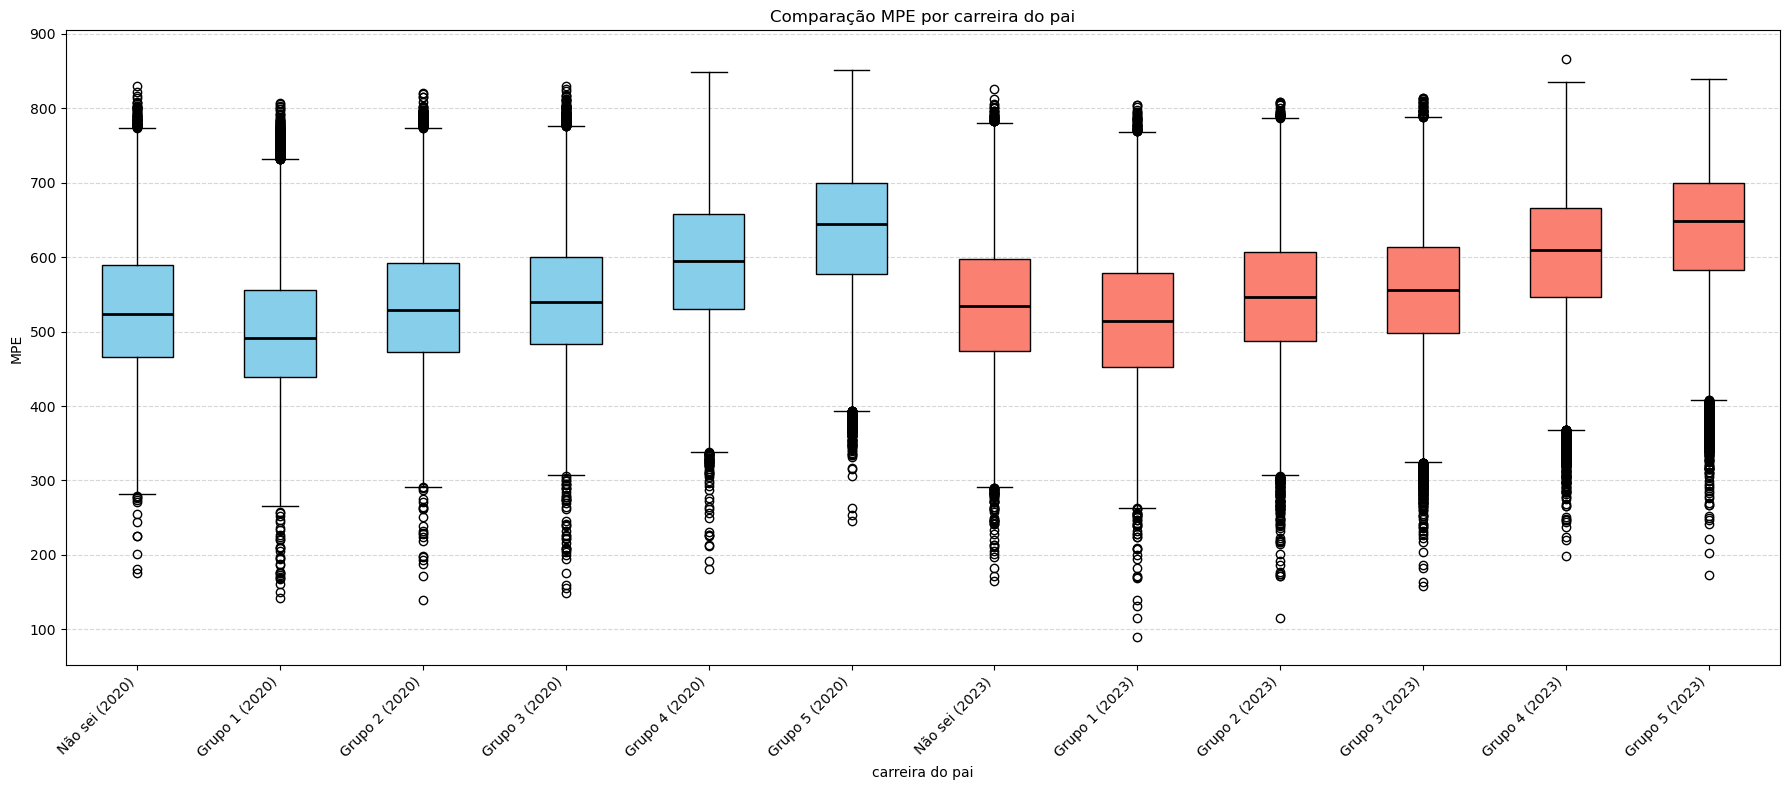

In [59]:
cat = ['Não sei','Grupo 1','Grupo 2','Grupo 3','Grupo 4','Grupo 5']

data = []
labels = []

for i in cat:
    grupo = dados2020.loc[dados2020['grupo_social_1'] == i, 'TARGET'].dropna()
    if len(grupo) > 0:
        data.append(grupo)
        labels.append(f'{i} (2020)')

for i in cat:
    grupo = dados2023.loc[dados2023['grupo_social_1'] == i, 'TARGET'].dropna()
    if len(grupo) > 0:
        data.append(grupo)
        labels.append(f'{i} (2023)')

plt.figure(figsize=(18, 8))

box = plt.boxplot(
    data,
    tick_labels=labels,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)

for i, b in enumerate(box['boxes']):
    if i < sum(len(dados2020.loc[dados2020['grupo_social_1'] == x, 'TARGET'].dropna()) > 0 for x in cat):
        b.set_facecolor('skyblue')
    else:
        b.set_facecolor('salmon')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.title('Comparação MPE por carreira do pai')
plt.ylabel('MPE')
plt.xlabel('carreira do pai')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

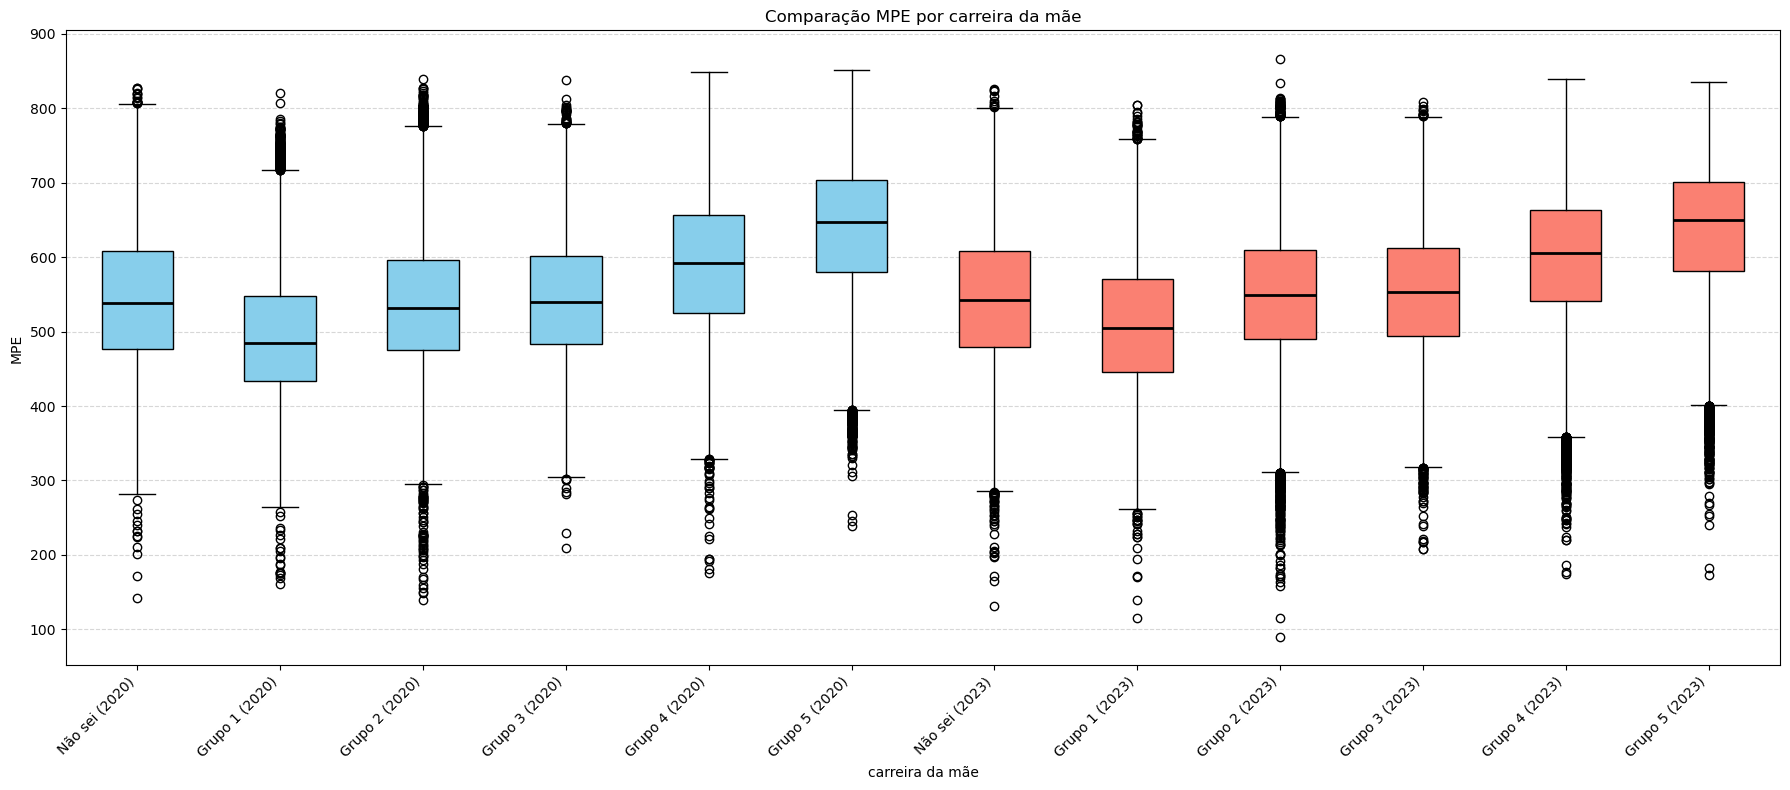

In [60]:
cat = ['Não sei','Grupo 1','Grupo 2','Grupo 3','Grupo 4','Grupo 5']

data = []
labels = []

for i in cat:
    grupo = dados2020.loc[dados2020['grupo_social_2'] == i, 'TARGET'].dropna()
    if len(grupo) > 0:
        data.append(grupo)
        labels.append(f'{i} (2020)')

for i in cat:
    grupo = dados2023.loc[dados2023['grupo_social_2'] == i, 'TARGET'].dropna()
    if len(grupo) > 0:
        data.append(grupo)
        labels.append(f'{i} (2023)')

plt.figure(figsize=(18, 8))

box = plt.boxplot(
    data,
    tick_labels=labels,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)

for i, b in enumerate(box['boxes']):
    if i < sum(len(dados2020.loc[dados2020['grupo_social_2'] == x, 'TARGET'].dropna()) > 0 for x in cat):
        b.set_facecolor('skyblue')
    else:
        b.set_facecolor('salmon')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.title('Comparação MPE por carreira da mãe')
plt.ylabel('MPE')
plt.xlabel('carreira da mãe')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Resultado: 
Observa-se um aumento consistente da mediana conforme aumentam a renda familiar, o nível de escolaridade dos pais e a qualificação de suas carreiras. Esses fatores apresentam um padrão associado, sugerindo um forte componente socioeconômico no desempenho dos estudantes.

Essa relação pode refletir diferenças no acesso a recursos educacionais, incentivo ao estudo, rede de apoio familiar e oportunidades, como a possibilidade de frequentar escolas privadas ou cursinhos.

## Comparando afinidade digital com Desempenho

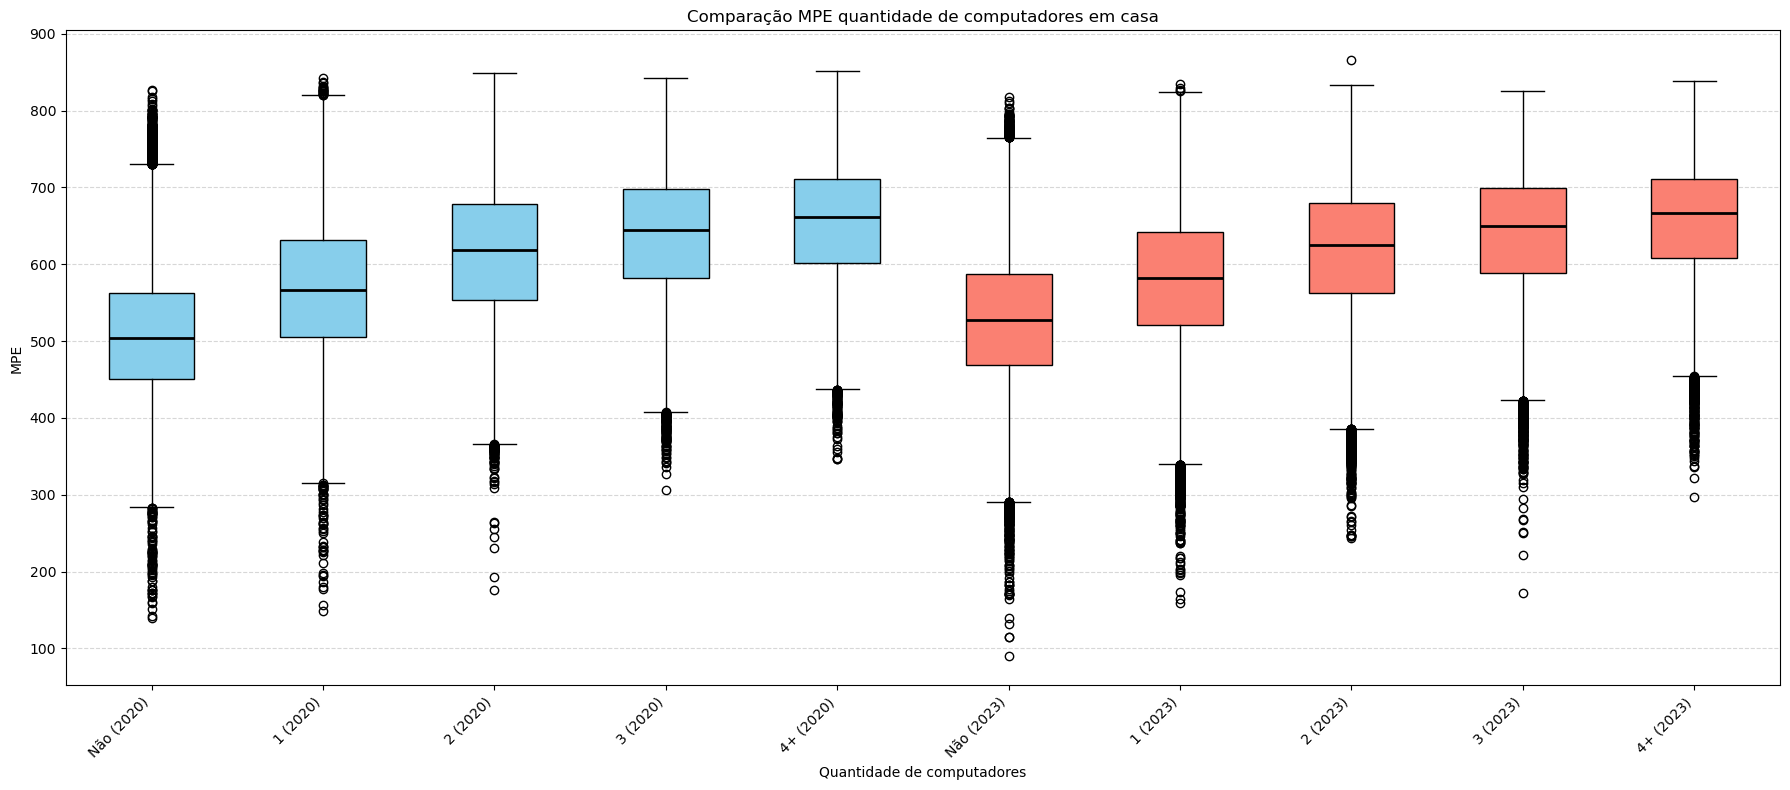

In [61]:
cat = ['Não','1','2','3','4+']

data = []
labels = []

for i in cat:
    grupo = dados2020.loc[dados2020['computador'] == i, 'TARGET'].dropna()
    if len(grupo) > 0:
        data.append(grupo)
        labels.append(f'{i} (2020)')

for i in cat:
    grupo = dados2023.loc[dados2023['computador'] == i, 'TARGET'].dropna()
    if len(grupo) > 0:
        data.append(grupo)
        labels.append(f'{i} (2023)')

plt.figure(figsize=(18, 8))

box = plt.boxplot(
    data,
    tick_labels=labels,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)

for i, b in enumerate(box['boxes']):
    if i < sum(len(dados2020.loc[dados2020['computador'] == x, 'TARGET'].dropna()) > 0 for x in cat):
        b.set_facecolor('skyblue')
    else:
        b.set_facecolor('salmon')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.title('Comparação MPE quantidade de computadores em casa')
plt.ylabel('MPE')
plt.xlabel('Quantidade de computadores')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

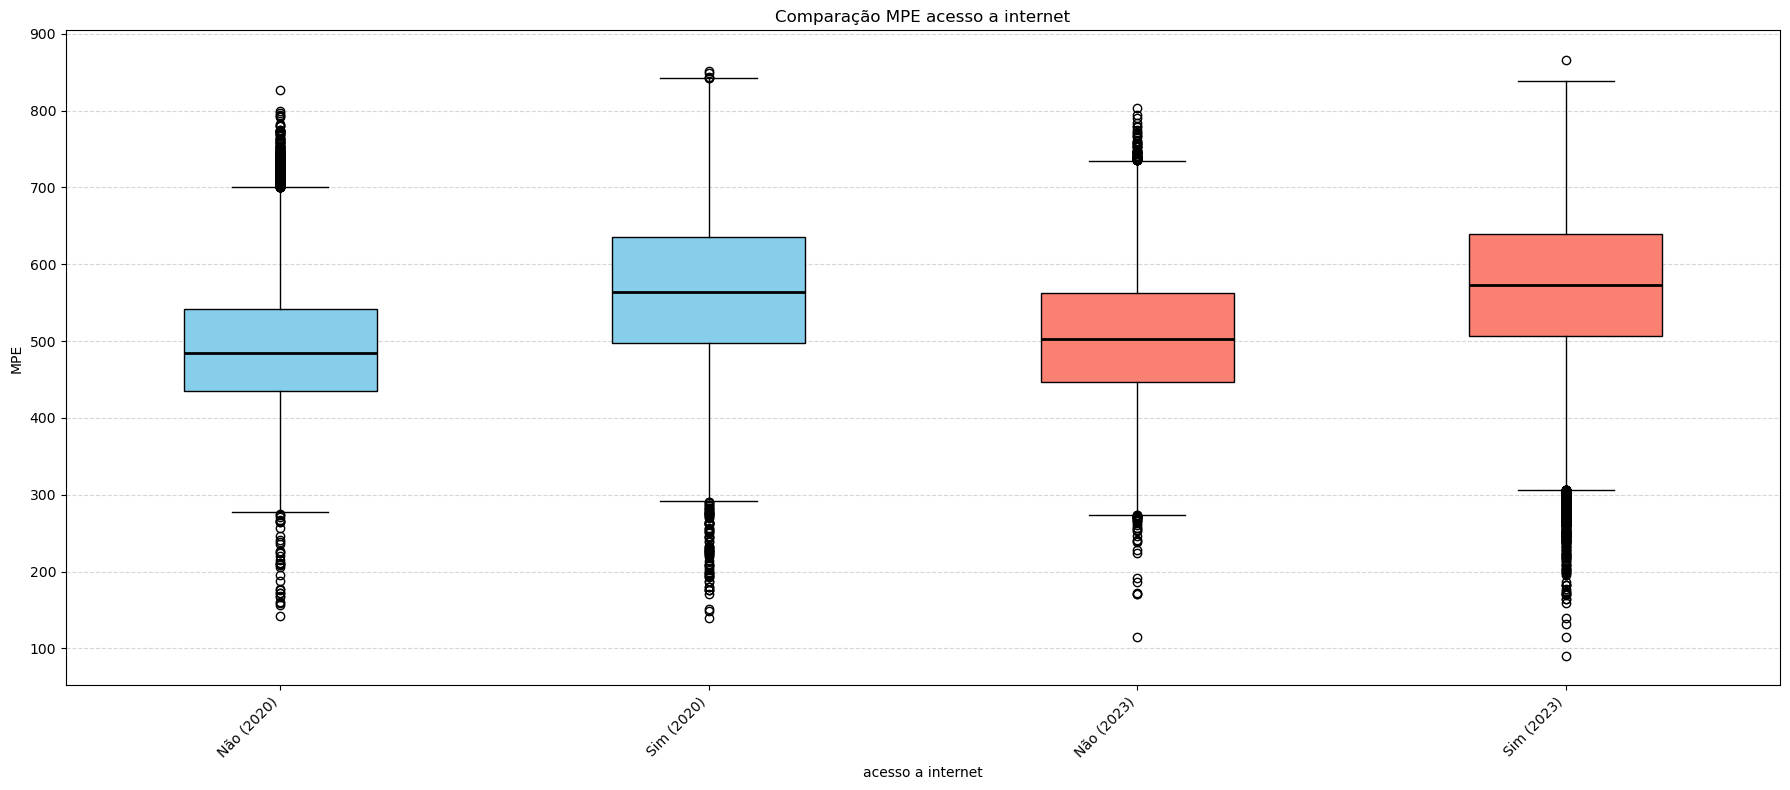

In [62]:
cat=['Não','Sim']
data = []
labels = []

for i in cat:
    grupo = dados2020.loc[dados2020['internet'] == i, 'TARGET'].dropna()
    if len(grupo) > 0:
        data.append(grupo)
        labels.append(f'{i} (2020)')

for i in cat:
    grupo = dados2023.loc[dados2023['internet'] == i, 'TARGET'].dropna()
    if len(grupo) > 0:
        data.append(grupo)
        labels.append(f'{i} (2023)')

plt.figure(figsize=(18, 8))

box = plt.boxplot(
    data,
    tick_labels=labels,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)

for i, b in enumerate(box['boxes']):
    if i < sum(len(dados2020.loc[dados2020['internet'] == x, 'TARGET'].dropna()) > 0 for x in cat):
        b.set_facecolor('skyblue')
    else:
        b.set_facecolor('salmon')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.title('Comparação MPE acesso a internet')
plt.ylabel('MPE')
plt.xlabel('acesso a internet')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Resultados:
O acesso a computadores e à internet também apresenta uma associação clara com o desempenho dos estudantes, com medianas mais altas entre aqueles que possuem esses recursos. Esses fatores estão fortemente relacionados a condições socioeconômicas e podem refletir maior acesso a materiais de estudo, informação e apoio educacional. Observa-se que esse padrão ocorre tanto durante o período da pandemia quanto após, indicando que o acesso a tecnologias digitais continua sendo uma vantagem relevante no desempenho acadêmico.

---
### Dashboard de Visualização

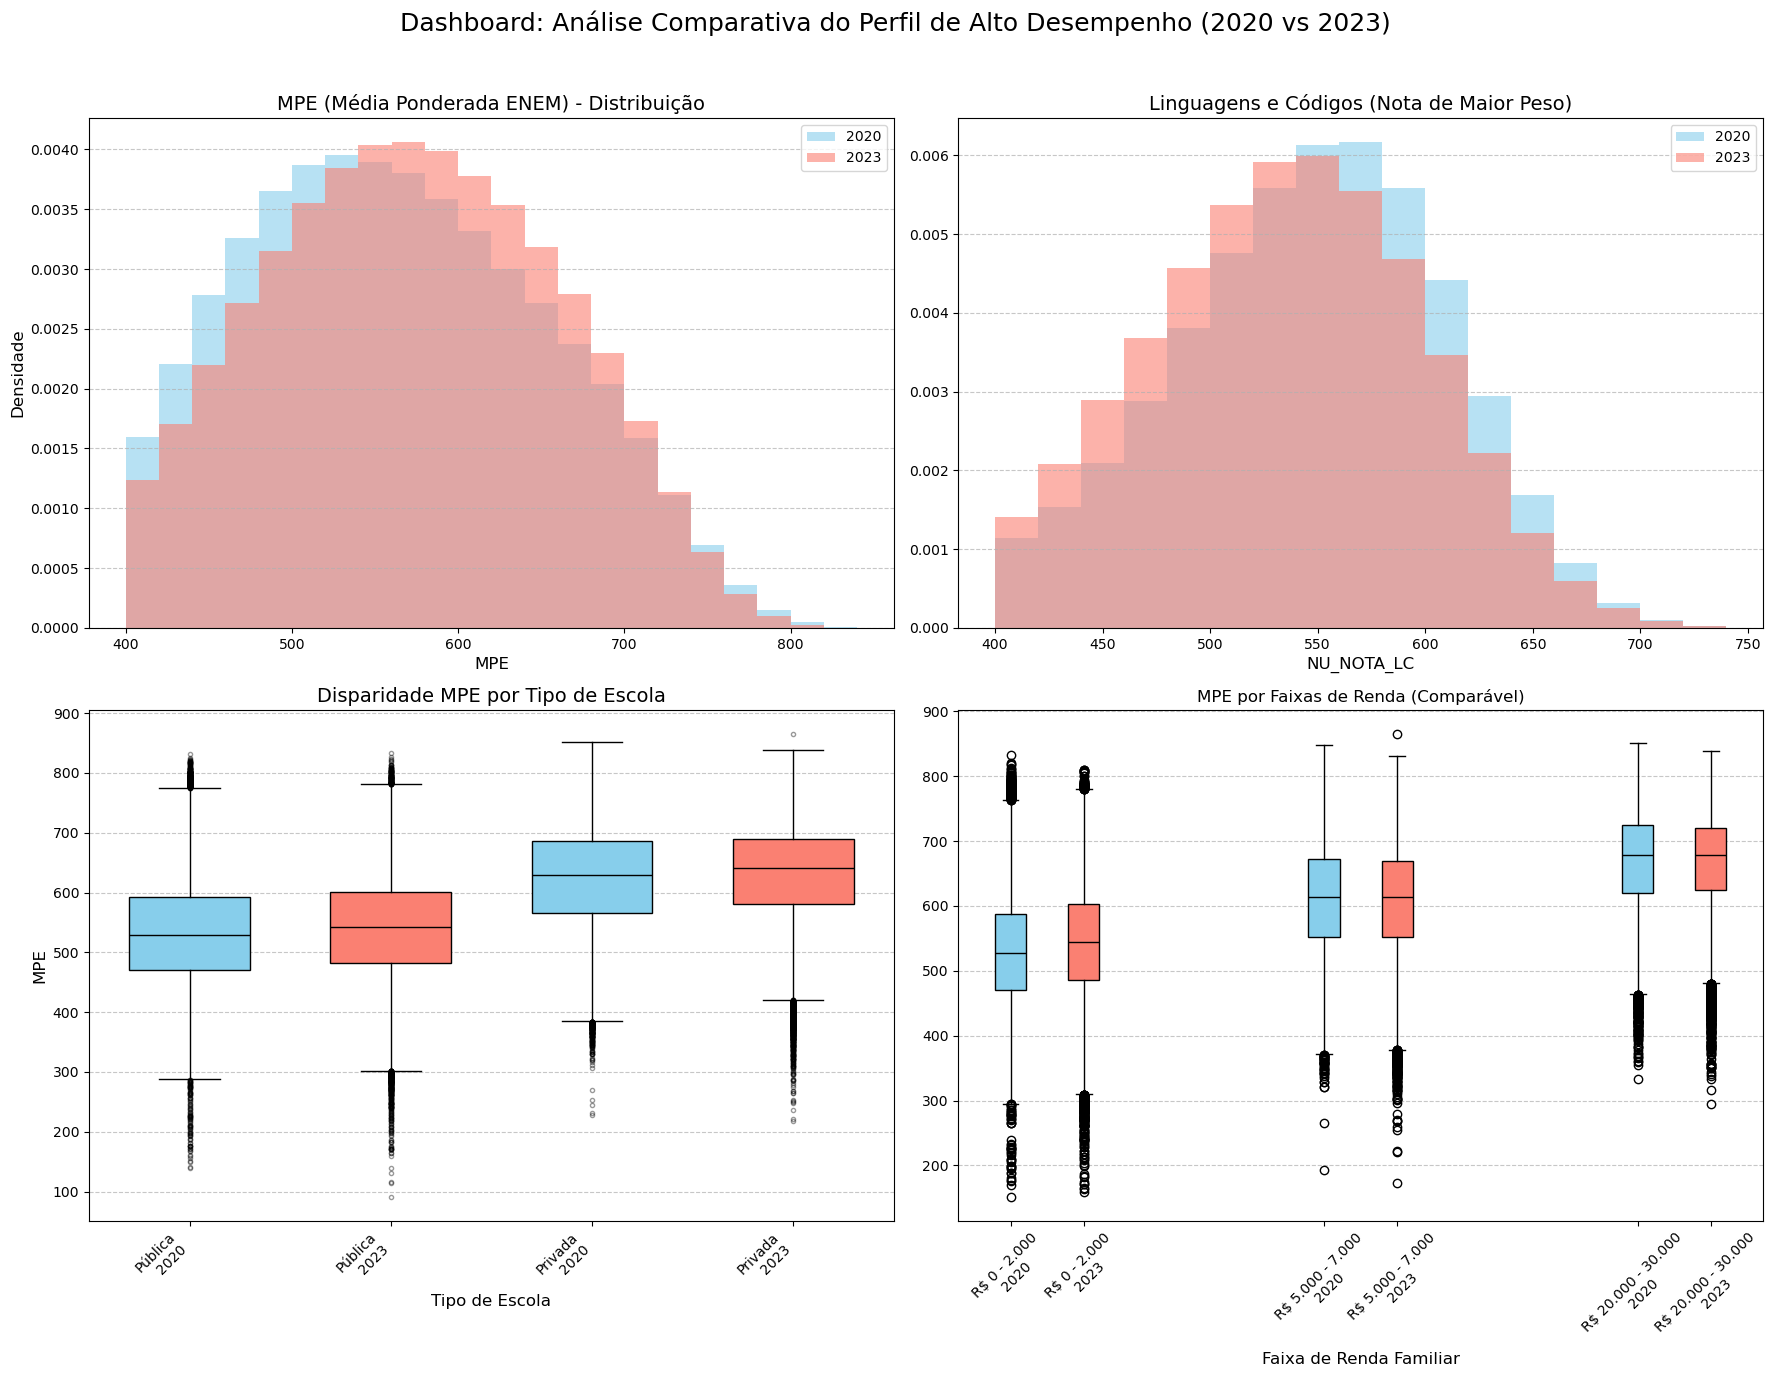

In [80]:
# DASHBOARD DE VISUALIZAÇÃO INTEGRADO 

# Preparação dos Dados
mpe_bins = np.arange(400, 850, 20)
lc_bins = np.arange(400, 750, 20) 

# Preparação dos DataFrames para BoxPlot
df20_temp = dados2020.copy()
df23_temp = dados2023.copy()
df20_temp['Ano'] = '2020'
df23_temp['Ano'] = '2023'
df_comparativo = pd.concat([df20_temp[['tipo_escola', 'renda', 'TARGET', 'Ano']], 
                            df23_temp[['renda', 'tipo_escola', 'TARGET', 'Ano']]],)


# Configuração Visual do Painel
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Dashboard: Análise Comparativa do Perfil de Alto Desempenho (2020 vs 2023)', fontsize=18)


# Histograma 1: TARGET
ax1 = axes[0, 0]
ax1.hist(dados2020['TARGET'].dropna(), bins=mpe_bins, color='skyblue', alpha=0.6, label='2020', density=True)
ax1.hist(dados2023['TARGET'].dropna(), bins=mpe_bins, color='salmon', alpha=0.6, label='2023', density=True)
ax1.set_title('MPE (Média Ponderada ENEM) - Distribuição', fontsize=14)
ax1.set_xlabel('MPE', fontsize=12)
ax1.set_ylabel('Densidade', fontsize=12)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)


# Histograma 2: Nota de Linguagens e Códigos (nota com maior peso)
ax2 = axes[0, 1]
ax2.hist(dados2020['NU_NOTA_LC'].dropna(), bins=lc_bins, color='skyblue', alpha=0.6, label='2020', density=True)
ax2.hist(dados2023['NU_NOTA_LC'].dropna(), bins=lc_bins, color='salmon', alpha=0.6, label='2023', density=True)
ax2.set_title('Linguagens e Códigos (Nota de Maior Peso)', fontsize=14)
ax2.set_xlabel('NU_NOTA_LC', fontsize=12)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)


# Boxplot 1: TARGET vs. tipo_escola
ax3 = axes[1, 0]
escola_cats = ['Pública', 'Privada']
data_escola = []
labels_escola_xticks = []
colors_escola_patches = []

for cat in escola_cats:
    data_escola.append(df_comparativo[(df_comparativo['tipo_escola'] == cat) & (df_comparativo['Ano'] == '2020')]['TARGET'].dropna().values)
    data_escola.append(df_comparativo[(df_comparativo['tipo_escola'] == cat) & (df_comparativo['Ano'] == '2023')]['TARGET'].dropna().values)
    labels_escola_xticks.append(f"{cat}\n2020")
    labels_escola_xticks.append(f"{cat}\n2023")
    colors_escola_patches.extend(['skyblue', 'salmon'])

# Remover elementos vazios, no caso de alguma categoria não conter dados 
data_escola = [d for d in data_escola if len(d) > 0]
colors_escola_patches = [c for c, d in zip(colors_escola_patches, data_escola) if len(d) > 0]
labels_escola_xticks = [l for l, d in zip(labels_escola_xticks, data_escola) if len(d) > 0]


box_parts_escola = ax3.boxplot(data_escola, 
                               positions=np.arange(1, len(data_escola) + 1),
                               widths=0.6, 
                               patch_artist=True,
                               medianprops=dict(color='black'),
                               flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, color in zip(box_parts_escola['boxes'], colors_escola_patches):
    patch.set_facecolor(color)

ax3.set_xticks(np.arange(1, len(data_escola) + 1), labels_escola_xticks, rotation=45, ha='right', fontsize=10)
ax3.set_title('Disparidade MPE por Tipo de Escola', fontsize=14)
ax3.set_xlabel('Tipo de Escola', fontsize=12)
ax3.set_ylabel('MPE', fontsize=12)
ax3.grid(axis='y', linestyle='--', alpha=0.7)


# GRÁFICO 4: MPE vs. Renda

# Função para converter renda em número:
def renda_para_num(valor):
    if pd.isna(valor):
        return np.nan

    valor = str(valor)

    if 'Sem renda' in valor:
        return 0

    if '+' in valor:
        return float(valor.replace('.', '').replace('+', ''))

    try:
        return float(valor.split('até')[0].replace('.', '').strip())
    except:
        return np.nan

df_comparativo['renda_num'] = df_comparativo['renda'].apply(renda_para_num)

# Escolher uma faixa de renda mínima, máxima e intermediária:
renda_cats_principais = [
    (0, 2000),      # mínima
    (5000, 7000),   # intermediária
    (20000, 30000)  # máxima
]

ax4 = axes[1, 1]

data_renda = []
positions = []
labels = []
colors = []

base_positions = [1, 4, 7]
offset = 0.35

for i, (min_r, max_r) in enumerate(renda_cats_principais):

    for ano, cor, shift in [('2020', 'skyblue', -offset),
                            ('2023', 'salmon', offset)]:

        valores = df_comparativo[
            (df_comparativo['Ano'] == ano) &
            (df_comparativo['renda_num'] >= min_r) &
            (df_comparativo['renda_num'] < max_r)
        ]['TARGET'].dropna().values

        if len(valores) > 0:
            data_renda.append(valores)
            positions.append(base_positions[i] + shift)
            labels.append(f"R$ {min_r:,.0f} - {max_r:,.0f}\n{ano}".replace(',', '.'))
            colors.append(cor)

box = ax4.boxplot(
    data_renda,
    positions=positions,
    widths=0.3,
    patch_artist=True,
    medianprops=dict(color='black')
)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

ax4.set_xticks(positions)
ax4.set_xlabel('Faixa de Renda Familiar', fontsize=12)
ax4.set_xticklabels(labels, rotation=45)
ax4.set_title('MPE por Faixas de Renda (Comparável)')
ax4.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.96]) 
plt.show()

___
### Análise Nota X Acertos

##### Separando o Grupo de Elite (MPE >= 650) e Todas as Notas >= 500

In [63]:
def filtrar_elite(df):
    # Filtra as notas brutas e a média final (TARGET)
    filtro = (
        (df['NU_NOTA_LC'] >= 500) & (df['NU_NOTA_MT'] >= 500) &
        (df['NU_NOTA_CH'] >= 500) & (df['NU_NOTA_CN'] >= 500) &
        (df['NU_NOTA_REDACAO'] >= 500) & 
        (df['TARGET'] >= 650)
    )
    return df.loc[filtro].copy()

# Criando os novos dataframes usando os seus "dados2020" e "dados2023"
elite_2020 = filtrar_elite(dados2020)
elite_2023 = filtrar_elite(dados2023)

print(f"Total de candidatos 2020 (Elite - TARGET>=650): {len(elite_2020)}")
print(f"Total de candidatos 2023 (Elite - TARGET>=650): {len(elite_2023)}")

Total de candidatos 2020 (Elite - TARGET>=650): 88235
Total de candidatos 2023 (Elite - TARGET>=650): 125823


##### Gerando o gráfico de dispersão TARGET vs Nota de Linguagens e Códigos

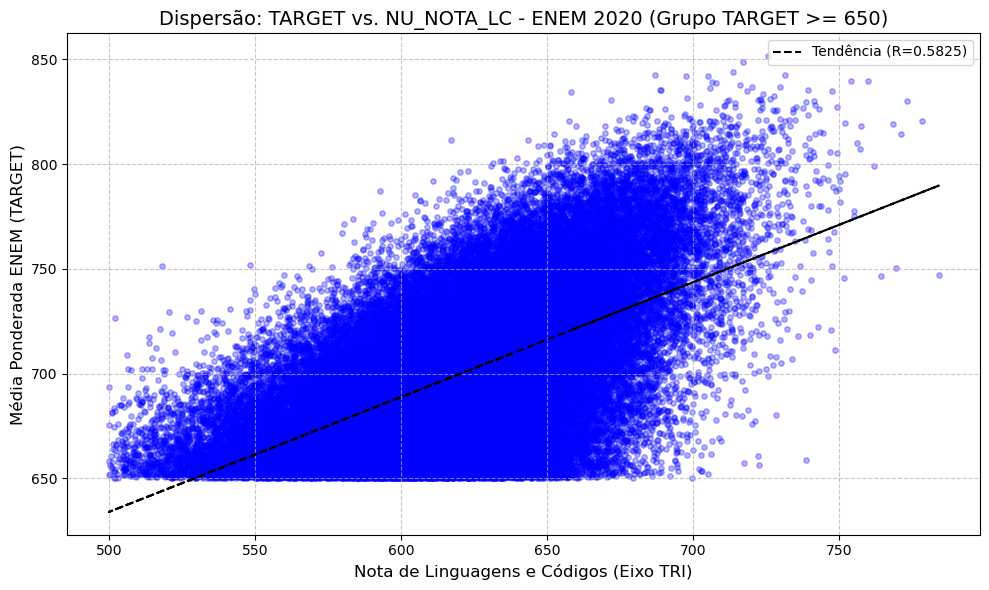

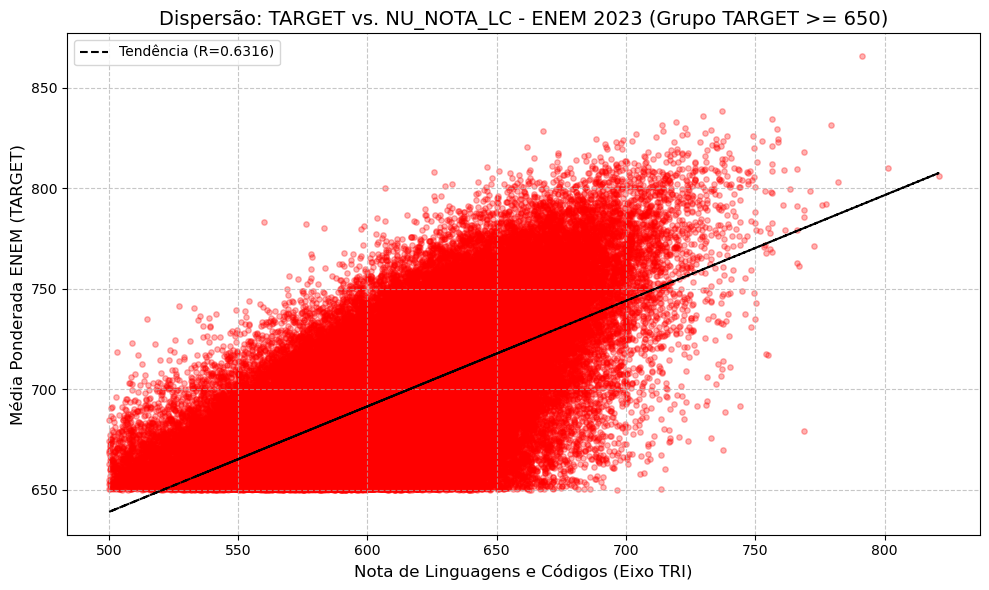

In [64]:
def scatter_correlation_LC(df, ano):
    
    # 1  -Conversão e Limpeza de Dados (Rigidez Estatística)
    df['NU_NOTA_LC'] = pd.to_numeric(df['NU_NOTA_LC'], errors='coerce')
    df['TARGET'] = pd.to_numeric(df['TARGET'], errors='coerce')
    df_plot = df.dropna(subset=['NU_NOTA_LC', 'TARGET']).copy()
    
    # 2 - Correlação de Pearson 
    corr_lc = df_plot['TARGET'].corr(df_plot['NU_NOTA_LC']).round(4)




    plt.figure(figsize=(10, 6))
    
    # Definindo a cor com base no ano (Azul para 2020, Vermelho para 2023)
    cor_pontos = 'blue' if ano == 2020 else 'red'
    
    # Plotando as "bolinhas" (Scatter)
    plt.scatter(
        df_plot['NU_NOTA_LC'], 
        df_plot['TARGET'], 
        alpha=0.3, # Transparência ajuda muito a ver onde os pontos se concentram
        s=15,      # Tamanho do ponto
        color=cor_pontos
    )
    
    # 3 - Linha de Tendência (Regressão Linear)
    z = np.polyfit(df_plot['NU_NOTA_LC'], df_plot['TARGET'], 1)
    p = np.poly1d(z)
    plt.plot(df_plot['NU_NOTA_LC'], p(df_plot['NU_NOTA_LC']), "k--", label=f'Tendência (R={corr_lc})')
    
    # 5. Ajustes Estéticos Finais
    plt.title(f'Dispersão: TARGET vs. NU_NOTA_LC - ENEM {ano} (Grupo TARGET >= 650)', fontsize=14)
    plt.xlabel('Nota de Linguagens e Códigos (Eixo TRI)', fontsize=12)
    plt.ylabel('Média Ponderada ENEM (TARGET)', fontsize=12)
    
    plt.legend()
    plt.grid(axis='both', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Chamando a função para gerar os dois gráficos na tela
scatter_correlation_LC(elite_2020, 2020)
scatter_correlation_LC(elite_2023, 2023)

### Interpretação 

Relação Nota de Linguagens e Códigos vs. TARGET

**Maior Peso na Composição da Nota Final:**
A nossa variável preditiva **TARGET** simula o comportamento da média ponderada exigida pelas universidades de alta concorrência para o curso de Direito. Na fórmula estipulada no tratamento de dados, a nota de Linguagens e Códigos (`NU_NOTA_LC`) foi parametrizada com peso 4 (0.40), tornando-se um dos eixos mais influentes na aprovação final.

**Análise de Dispersão no Grupo de Elite:**
O gráfico de dispersão isola os candidatos competitivos (`TARGET` >= 650 pontos e notas base >= 500). O cálculo do coeficiente de correlação de Pearson (R) e a inclinação da linha de tendência evidenciam de forma matemática a dependência do `TARGET` em relação ao `NU_NOTA_LC`. Observa-se que, devido ao peso agressivo, o déficit na área de Linguagens cria um "teto" invisível, dificultando substancialmente que o candidato atinja o patamar de aprovação apenas compensando a nota com acertos em áreas de menor peso (como Ciências da Natureza).

___

# 4 - Conclusão